# Start time updates 

In [1]:
# import necessary and useful packages
import os
import numpy as np
import matplotlib.pyplot as plt
import colorcet
import cycler
import pandas as pd
import rubin_sim.maf as maf

This notebook explores summary metric comparison across different survey start times. 

Jump to comparison of metrics targeting: 
* [SCOC overview](#SCOC)
* [Science Requirements Document](#SRD)
* [DESC WFD coverage](#DESCWFD)
* [Transient and Variable Stars](#TVS)
* [Solar System Objects](#SSO)
* [Active Galactic Nuclei](#AGN)
* [Galaxies](#Galaxies)
* [Strong Lensing](#StrongLensing)
* [Stars](#Stars)
* [Milky Way and Local Volume](#MWLV)

## Get background information about summary statistics

Read the information about the metric sets in this version of the sims outputs. The metric_sets defines groups of summary statistics that have been identified as likely relevant for comparing simulations for particular science purposes. 

In [2]:
metrics = maf.get_metric_subsets('metric_subsets.json')
msets = list(metrics.groupby('metric subset').first().index)

In [3]:
summaries = maf.get_metric_summaries(summary_source='summary.h5')
print(f"This summary h5 file contains information on {len(summaries.index)} simulations.")
print(summaries.index)

This summary h5 file contains information on 59 simulations.
Index(['all_early_v4.3.2_10yrs', 'baseline_v2.0_10yrs', 'baseline_v2.1_10yrs',
       'baseline_v2.2_10yrs', 'baseline_v3.0_10yrs', 'baseline_v3.2_10yrs',
       'baseline_v3.3_10yrs', 'baseline_v3.4_10yrs', 'baseline_v3.5_10yrs',
       'baseline_v3.6_10yrs', 'baseline_v4.0_10yrs', 'baseline_v4.1_10yrs',
       'baseline_v4.2_10yrs', 'baseline_v4.3.1_10yrs', 'baseline_v4.3.2_10yrs',
       'ddf_accor_skipizy_v4.3.2_10yrs', 'ddf_accor_v4.3.2_10yrs',
       'ddf_daily_v4.3.2_10yrs', 'ddf_roll__1_v4.3.1_10yrs',
       'ddf_roll_baseline_v4.3.2_10yrs', 'desc_ddf_gen_0.70_co_v4.3.1_10yrs',
       'desc_ddf_gen_0.70_sn_v4.3.1_10yrs', 'desc_ddf_gen_0.70_v4.3.1_10yrs',
       'desc_ddf_gen_0.70_wz_v4.3.1_10yrs',
       'desc_ddf_gen_0.75_co_v4.3.1_10yrs',
       'desc_ddf_gen_0.75_sn_v4.3.1_10yrs',
       'desc_ddf_gen_0.75_wz_v4.3.1_10yrs',
       'desc_ddf_gen_0.80_co_v4.3.1_10yrs',
       'desc_ddf_gen_0.80_sn_v4.3.1_10yrs', 'des

In [4]:
m5_SRD_design = {'u': 23.90, 'g': 25.00, 'r': 24.70, 'i': 24.00, 'z': 23.30, 'y': 22.10}
m5_SRD_minimum = {'u': 23.40, 'g':24.60, 'r': 24.30, 'i': 23.60, 'z': 22.90, 'y': 21.70}

# Weather variations on baseline strategy
weather_runs = [r for r in summaries.index if 'weather' in r]
offsets = [int(w.split('dso')[-1].split('v4')[0]) for w in weather_runs]
idx = np.argsort(offsets)
weather_runs = [weather_runs[i] for i in idx]
print("weather runs", len(weather_runs))

# Start date variations
start_dates = [r for r in summaries.index if 'start_date' in r]
offsets = [int(r.split('mjdp')[-1].split('_')[0]) for r in start_dates]
idx = np.argsort(offsets)
start_dates = [start_dates[i] for i in idx]
print("start_dates", len(start_dates))


# Baseline sims, and put them in order of evolution

baseline_dict = {'retro_baseline_v2.0_10yrs': 'v1.x', 
                 'baseline_v2.0_10yrs':'v2.0', 
                 'baseline_v2.1_10yrs':'v2.1',
                 'baseline_v2.2_10yrs':'v2.2',
                 'baseline_v3.0_10yrs':'v3.0',
                 'baseline_v3.2_10yrs':'v3.2',
                'baseline_v3.3_10yrs':'v3.3',
                'baseline_v3.4_10yrs': 'v3.4',
                'baseline_v3.5_10yrs': 'v3.5', 
                 'baseline_v3.6_10yrs': 'v3.6',
                 'baseline_v4.0_10yrs': 'v4.0',
                }

newbaselines_dict = {'baseline_v4.3.2_10yrs': 'baseline v4.3.2', 
                     'baseline_v4.3.1_10yrs': "baseline v4.3.1",
                     'four_roll_v4.3.1_10yrs': "four cycle v4.3.1",
                    'one_snap_v4.3.1_10yrs' : "one snap v4.3.1",                     
                    }

rdict = {}
for k in baseline_dict:
    rdict[k] = baseline_dict[k]
for k in newbaselines_dict:
    rdict[k] = newbaselines_dict[k]

runs = list(rdict.keys())
baseline = 'baseline_v4.3.1_10yrs'

outdir = 'tmp_fig'
try:
    os.mkdir(outdir)
except:
    pass

weather runs 14
start_dates 4


We can derive approximate uncertainties for some of our relevant metrics by looking at their variation across the different 'weather' instances of the baseline strategy.
This isn't necessarily appropriate for all metrics, but it does give a useful indications.

In [5]:
dev = np.std(summaries.loc[weather_runs], axis=0)
hilo = np.abs(summaries.loc[weather_runs].max() - summaries.loc[weather_runs].min())


In [6]:
from matplotlib.colors import LinearSegmentedColormap, ListedColormap

#filter_colors = {"u": "cyan", "g": "g", "r": "orange", "i": "r", "z": "m", "y": "b"}
filter_colors = {'u': '#0c71ff', 'g': '#49be61', 'r': '#c61c00', 'i': '#ffc200', 'z': '#f341a2', 'y': '#5d0000'}

filter_rgb_map = {
    "u": (74 / 256, 125 / 256, 179 / 256),
    "g": (104 / 256, 173 / 256, 87 / 256),
    "r": (238 / 256, 134 / 256, 50 / 256),
    "i": (232 / 256, 135 / 256, 189 / 256),
    "z": (209 / 256, 53 / 256, 43 / 256),
    "y": (142 / 256, 82 / 256, 159 / 256),
}

#filter_color_map = ListedColormap(list(filter_rgb_map.values()))
filter_color_map = ListedColormap(list(filter_colors.values()))

## Start time updates

From v4.0 to v4.3, the start time was updated -  moving from May 1, 2025 to November 1, 2025. 
This notebook looks at a range of start times over the year, to look at the impact of start time and to show that v4.0 metric results are consistent with v4.3, once uncertainties due to start time are included. 

In [7]:
runs = ['baseline_v4.0_10yrs', 'baseline_v4.3.1_10yrs', 'baseline_v4.3.2_10yrs', 'four_roll_v4.3.1_10yrs'] + start_dates
rdict = dict([(r, r.replace("_10yrs", "")) for r in runs])
rdict

{'baseline_v4.0_10yrs': 'baseline_v4.0',
 'baseline_v4.3.1_10yrs': 'baseline_v4.3.1',
 'baseline_v4.3.2_10yrs': 'baseline_v4.3.2',
 'four_roll_v4.3.1_10yrs': 'four_roll_v4.3.1',
 'start_date_mjdp90_v4.3.1_10yrs': 'start_date_mjdp90_v4.3.1',
 'start_date_mjdp180_v4.3.1_10yrs': 'start_date_mjdp180_v4.3.1',
 'start_date_mjdp270_v4.3.1_10yrs': 'start_date_mjdp270_v4.3.1',
 'start_date_mjdp360_v4.3.1_10yrs': 'start_date_mjdp360_v4.3.1'}

In [8]:
summaries.loc[runs, [c for c in summaries.columns if "Median Median" in c and "Healpix" in c and 'all bands' in c]]

metric,Median Median HA All sky all bands HealpixSlicer,Median Median HA WFD all bands HealpixSubsetSlicer,Median Median Inter-Night Gap All sky all bands HealpixSlicer,Median Median Inter-Night Gap WFD all bands HealpixSubsetSlicer,Median Median Season Length All sky all bands HealpixSlicer,Median Median Season Length WFD all bands HealpixSubsetSlicer,Median Median airmass All sky all bands HealpixSlicer,Median Median airmass WFD all bands HealpixSubsetSlicer,Median Median airmass Yr 1 all bands HealpixSlicer,Median Median fiveSigmaDepth All sky all bands HealpixSlicer,...,Median Median saturation_mag WFD all bands HealpixSubsetSlicer,Median Median seeingEff All sky all bands HealpixSlicer,Median Median seeingEff WFD all bands HealpixSubsetSlicer,Median Median seeingEff Yr 1 all bands HealpixSlicer,Median Median seeingGeom Yr 1 all bands HealpixSlicer,Median Median skyBrightness All sky all bands HealpixSlicer,Median Median skyBrightness WFD all bands HealpixSubsetSlicer,Median Median skyBrightness Yr 1 all bands HealpixSlicer,Median Median solarElong All sky all bands HealpixSlicer,Median Median solarElong WFD all bands HealpixSubsetSlicer
run,,,,,,,,,,,,,,,,,,,,,
baseline_v4.0_10yrs,0.665026,0.829653,3.135352,3.003853,167.657561,175.212667,1.172602,1.159966,1.168973,23.352648,...,14.119993,1.057335,1.039395,0.976845,0.854967,19.807028,19.751562,19.756678,131.707714,131.194094
baseline_v4.3.1_10yrs,0.682627,1.035022,3.758346,3.020103,174.217484,182.279668,1.184947,1.175542,1.179229,23.335003,...,14.090963,1.070169,1.052026,0.989765,0.865587,19.783738,19.726017,19.681727,130.288748,130.004745
baseline_v4.3.2_10yrs,0.697500,1.054408,3.736077,3.015561,174.648732,182.646159,1.185637,1.175558,1.177625,23.335321,...,14.089951,1.068446,1.051099,0.986911,0.863241,19.786490,19.725838,19.705683,130.264707,130.141753
four_roll_v4.3.1_10yrs,0.771989,1.145378,3.037288,2.987801,173.746087,180.647317,1.187769,1.177735,1.179229,23.322429,...,14.077138,1.071997,1.055699,0.989765,0.865587,19.763671,19.706968,19.681727,130.520664,130.512293
start_date_mjdp90_v4.3.1_10yrs,0.623710,0.883882,3.082768,2.993370,169.634819,177.655881,1.183040,1.173204,1.185483,23.359511,...,14.125590,1.058754,1.038159,0.941229,0.825690,19.819034,19.769334,19.905677,131.211482,131.080169
start_date_mjdp180_v4.3.1_10yrs,0.655921,0.999603,3.121415,3.001574,168.768742,177.735035,1.186289,1.174680,1.178209,23.348163,...,14.125583,1.060974,1.038942,0.966509,0.846471,19.786997,19.734477,19.769050,130.862320,130.561385
start_date_mjdp270_v4.3.1_10yrs,0.639876,0.952095,3.085221,3.000751,171.238013,177.723948,1.183502,1.173273,1.179613,23.349187,...,14.115656,1.065491,1.044998,1.028176,0.897160,19.802930,19.748644,19.754377,130.618036,130.472471
start_date_mjdp360_v4.3.1_10yrs,0.717645,1.045208,3.744746,3.018203,174.686336,182.664853,1.185150,1.175417,1.182560,23.337553,...,14.103527,1.071257,1.046479,0.993314,0.868504,19.793593,19.736470,19.760967,130.705811,130.106920


metric,Median CoaddM5 WFD u band HealpixSubsetSlicer,Median CoaddM5 WFD g band HealpixSubsetSlicer,Median CoaddM5 WFD r band HealpixSubsetSlicer,Median CoaddM5 WFD i band HealpixSubsetSlicer,Median CoaddM5 WFD z band HealpixSubsetSlicer,Median CoaddM5 WFD y band HealpixSubsetSlicer,Mean Median fiveSigmaDepth WFD u band HealpixSubsetSlicer,Mean Median fiveSigmaDepth WFD g band HealpixSubsetSlicer,Mean Median fiveSigmaDepth WFD r band HealpixSubsetSlicer,Mean Median fiveSigmaDepth WFD i band HealpixSubsetSlicer,Mean Median fiveSigmaDepth WFD z band HealpixSubsetSlicer,Mean Median fiveSigmaDepth WFD y band HealpixSubsetSlicer,Median NVisits WFD u band HealpixSubsetSlicer,Median NVisits WFD g band HealpixSubsetSlicer,Median NVisits WFD r band HealpixSubsetSlicer,Median NVisits WFD i band HealpixSubsetSlicer,Median NVisits WFD z band HealpixSubsetSlicer,Median NVisits WFD y band HealpixSubsetSlicer
run,,,,,,,,,,,,,,,,,,
baseline_v4.0_10yrs,25.599751,26.834632,26.940862,26.428239,25.759772,24.797671,23.380392,24.446774,24.052966,23.525270,22.941471,22.005331,54.0,66.0,174.0,176.0,158.0,155.0
baseline_v4.3.1_10yrs,25.576321,26.810699,26.912422,26.397727,25.750736,24.769059,23.364077,24.421969,24.025990,23.504095,22.938610,21.987308,53.0,65.0,173.0,173.0,156.0,152.0
baseline_v4.3.2_10yrs,25.573098,26.800832,26.908999,26.400774,25.751765,24.770648,23.359807,24.419127,24.023160,23.501243,22.940272,21.986370,53.0,65.0,173.0,173.0,156.0,152.0
four_roll_v4.3.1_10yrs,25.578533,26.797796,26.906292,26.395058,25.744162,24.778756,23.360028,24.415941,24.017081,23.493973,22.933074,21.988106,53.0,65.0,173.0,174.0,156.0,153.0
start_date_mjdp90_v4.3.1_10yrs,25.612579,26.836650,26.933660,26.423873,25.760852,24.792026,23.380217,24.436659,24.043507,23.524090,22.946605,22.004649,54.0,66.0,174.0,176.0,157.0,153.0
start_date_mjdp180_v4.3.1_10yrs,25.591230,26.847257,26.926533,26.419379,25.763286,24.789915,23.364756,24.449419,24.034344,23.516469,22.948775,22.001011,54.0,67.0,175.0,177.0,158.0,154.0
start_date_mjdp270_v4.3.1_10yrs,25.595880,26.836798,26.921990,26.418999,25.758079,24.784974,23.361610,24.433542,24.036212,23.519336,22.947252,22.000208,54.0,66.0,174.0,175.0,156.0,153.0
start_date_mjdp360_v4.3.1_10yrs,25.582815,26.832218,26.920212,26.411709,25.757743,24.776244,23.347133,24.425206,24.029189,23.509846,22.941688,21.986324,54.0,66.0,174.0,176.0,157.0,153.0


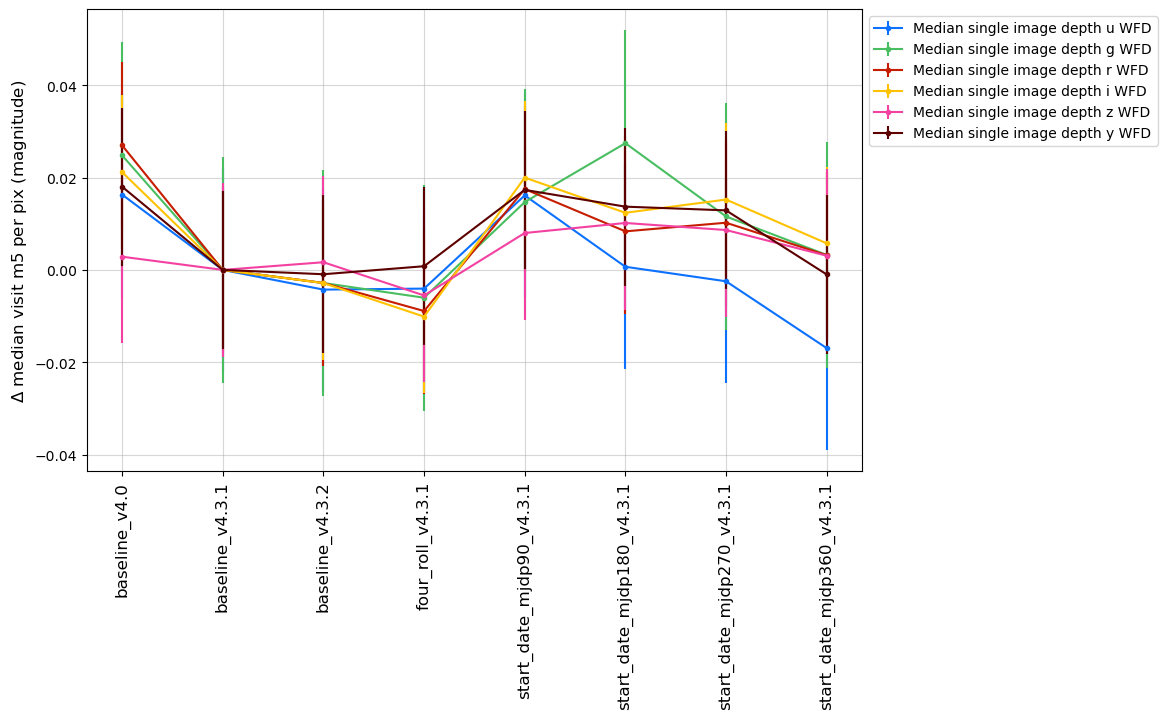

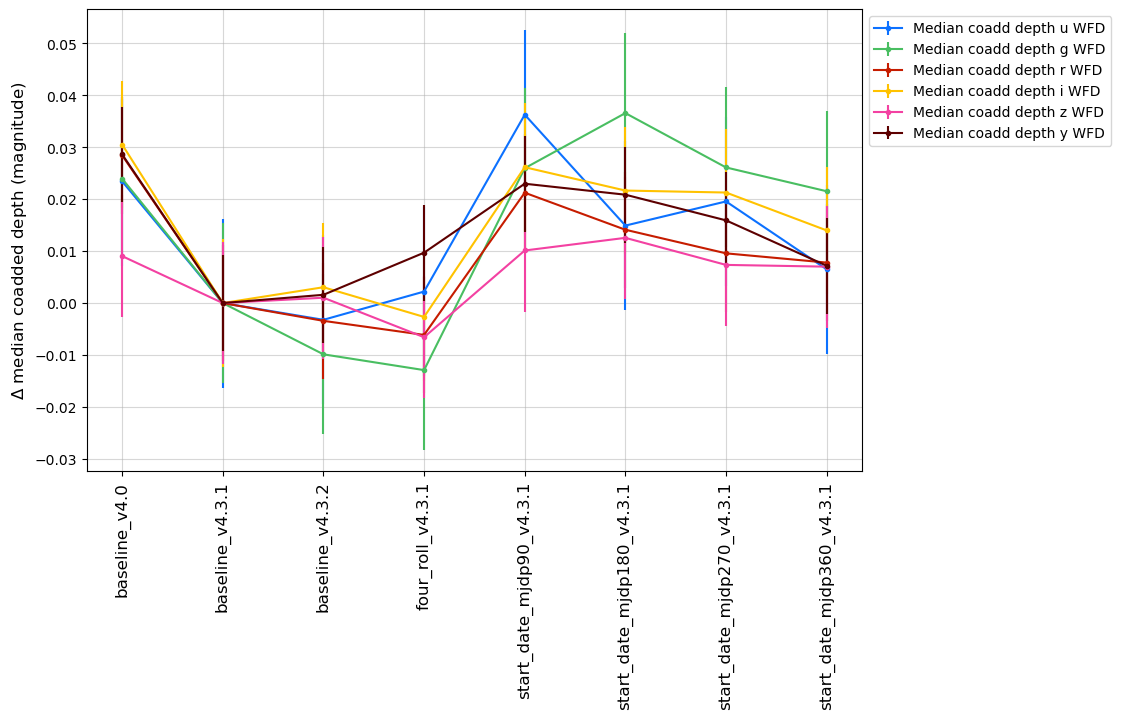

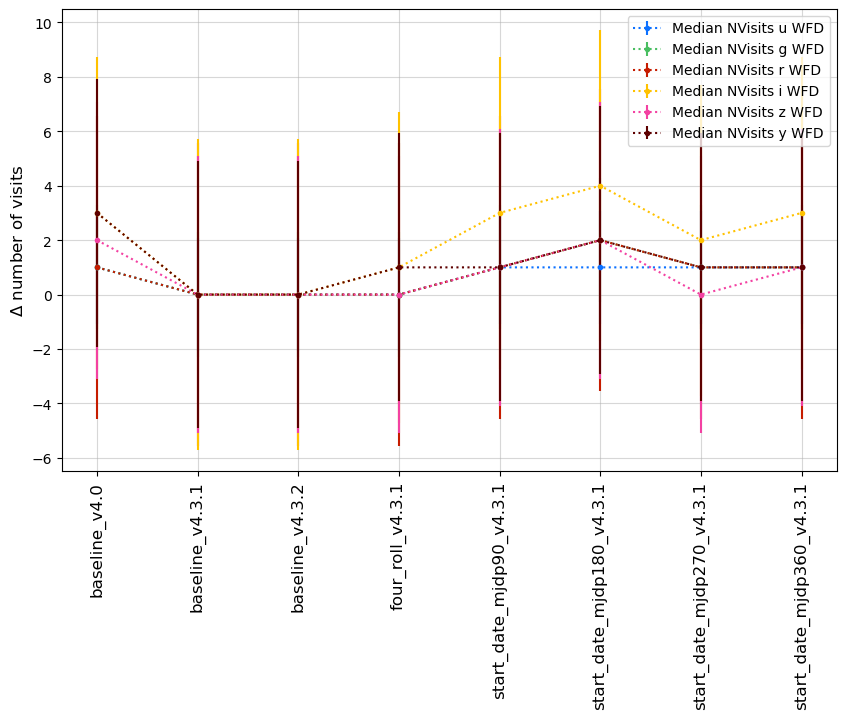

In [9]:
# Check in on the depths and number of visits in each bandpass
k = 'WFD Depths'

msub = metrics.loc[k].query('metric.str.contains("Mean Median")')
fig, ax = maf.plot_run_metric_uncert(summaries.loc[runs, msub['metric']] - summaries.loc[baseline, msub['metric']], 
                                 dev[msub['metric']], 
                                 metric_label_map=msub['short_name'], 
                                 run_label_map=rdict,
                                 metric_subset=msub,
                                 cmap=filter_color_map,
                                 sep_plots=False)
ax.set_ylabel(r"$\Delta$ median visit m5 per pix (magnitude)", fontsize='large')
y1, y2 = plt.ylim()
fig.savefig(os.path.join(outdir, 'visit_m5_per_pix' + '.png'), format='png')


msub = metrics.loc[k].query('metric.str.contains("Coadd")')
fig, ax = maf.plot_run_metric_uncert(summaries.loc[runs, msub['metric']] - summaries.loc[baseline, msub['metric']], 
                                 dev[msub['metric']], 
                                 metric_label_map=msub['short_name'], 
                                 run_label_map=rdict,
                                 metric_subset=msub,
                                 cmap=filter_color_map,
                                 sep_plots=False)
ax.set_ylabel(r"$\Delta$ median coadded depth (magnitude)", fontsize='large')
y1, y2 = plt.ylim()
fig.savefig(os.path.join(outdir, 'coadd_m5_per_pix' + '.png'), format='png')

msub = metrics.loc[k].query('metric.str.contains("NVisits")')
fig, ax = maf.plot_run_metric_uncert(summaries.loc[runs, msub['metric']] - summaries.loc[baseline, msub['metric']], 
                                 dev[msub['metric']], 
                                 metric_label_map=msub['short_name'], 
                                 run_label_map=rdict,
                                 metric_subset=msub,
                                 cmap=filter_color_map,
                                 sep_plots=False)
ax.set_ylabel(r"$\Delta$ number of visits", fontsize='large')
y1, y2 = plt.ylim()
fig.savefig(os.path.join(outdir, 'nvisit_per_pix'+ '.png'), format='png')

summaries.loc[runs, metrics.loc[k]['metric']] 

In [10]:
cols = [m for m in summaries if "Teff All sky all bands" in m and "UniSlicer" in m and "Normalized" not in m]
cols

d = summaries.loc[runs, cols]/summaries.loc[baseline, cols]
d = d.rename(columns={'Identity Total Teff All sky all bands UniSlicer': "Teff Total"})
d.round(2)

metric,Teff Total
run,
baseline_v4.0_10yrs,1.04
baseline_v4.3.1_10yrs,1.00
baseline_v4.3.2_10yrs,1.00
four_roll_v4.3.1_10yrs,0.99
start_date_mjdp90_v4.3.1_10yrs,1.03
start_date_mjdp180_v4.3.1_10yrs,1.03
start_date_mjdp270_v4.3.1_10yrs,1.02
start_date_mjdp360_v4.3.1_10yrs,1.01


And finally, let's have a look at those depths compared to SRD design and minimum goals, to evaluate how these changes are redistributing depth (or, in a sense, time) among bandpasses.

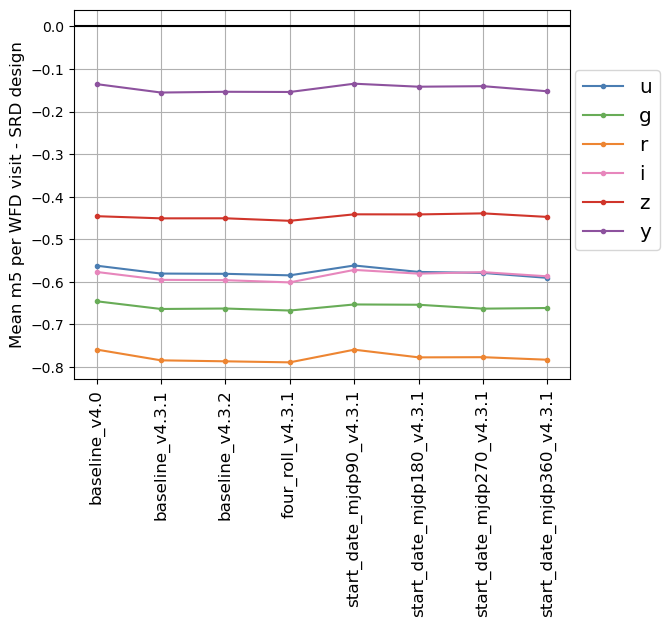

In [11]:
cols = [m for m in summaries if "fiveSigmaDepth" in m and 'band' in m and "UniSlicer" in m
             and ("Mean" in m) and "WFD" in m and "Yr 1" not in m and 'all' not in m]
cols = [f'Identity Mean fiveSigmaDepth WFD {f} band UniSlicer' for f in 'ugrizy']
newcols = [f'Mean m5 WFD {f} band per image' for f in 'ugrizy']
visitdepth_cols = cols

mset = maf.create_metric_subset('VisitDepths', metrics=cols, short_name=newcols, invert=False, mag=True) 

fig, ax = plt.subplots() 

for f, col in zip(['u', 'g', 'r', 'i', 'z', 'y'], cols):
    ax.plot(list(rdict.values()), summaries.loc[runs, col] - m5_SRD_design[f], 
                color=filter_rgb_map[f], marker='.', linestyle='-', label=f)
    #ax.axhline(m5_SRD_design[f], color=filter_colors[f], linestyle=':', linewidth=3)

ax.axhline(0, color='k', linestyle='-')
ax.set_ylabel(f"Mean m5 per WFD visit - SRD design", fontsize='large')
plt.legend(loc=(1.01, 0.35), fontsize='x-large')
ax.tick_params(axis='x', labelrotation = 90, labelsize='large')
ax.grid()
fig.savefig(os.path.join(outdir, 'm5_per_visit'+ '.png'), format='png')

In [12]:
## WFD coadd vs. exgal coadd depths 

k = 'WFD Depths'

msub = metrics.loc[k].query('metric.str.contains("Coadd")')
q1 = summaries.loc[runs, msub['metric']]
names = {}
for m in msub['metric']:
    names[m] = m.split(" band")[0][-1:]
q1.rename(columns=names, inplace=True)

mm = [f"Median Exgal_CoaddM5 WFD {f} band HealpixSubsetSlicer" for f in 'ugrizy']
q2 = summaries.loc[runs, mm]
names = {}
for m in metrics:
    names[m] = m.split(" band")[0][-1:]
q2.rename(columns=names, inplace=True)


summaries.loc[runs, mm].round(2)

metric,Median Exgal_CoaddM5 WFD u band HealpixSubsetSlicer,Median Exgal_CoaddM5 WFD g band HealpixSubsetSlicer,Median Exgal_CoaddM5 WFD r band HealpixSubsetSlicer,Median Exgal_CoaddM5 WFD i band HealpixSubsetSlicer,Median Exgal_CoaddM5 WFD z band HealpixSubsetSlicer,Median Exgal_CoaddM5 WFD y band HealpixSubsetSlicer
run,,,,,,
baseline_v4.0_10yrs,25.32,26.57,26.76,26.29,25.64,24.71
baseline_v4.3.1_10yrs,25.31,26.55,26.73,26.26,25.64,24.69
baseline_v4.3.2_10yrs,25.29,26.55,26.73,26.27,25.64,24.69
four_roll_v4.3.1_10yrs,25.30,26.54,26.73,26.26,25.63,24.69
start_date_mjdp90_v4.3.1_10yrs,25.33,26.58,26.76,26.30,25.65,24.71
start_date_mjdp180_v4.3.1_10yrs,25.32,26.59,26.75,26.29,25.65,24.71
start_date_mjdp270_v4.3.1_10yrs,25.32,26.58,26.75,26.29,25.64,24.70
start_date_mjdp360_v4.3.1_10yrs,25.31,26.58,26.75,26.28,25.64,24.69


## Evaluate metrics

Let's evaluate some metric results across these baseline surveys, starting with a very high level overview. 

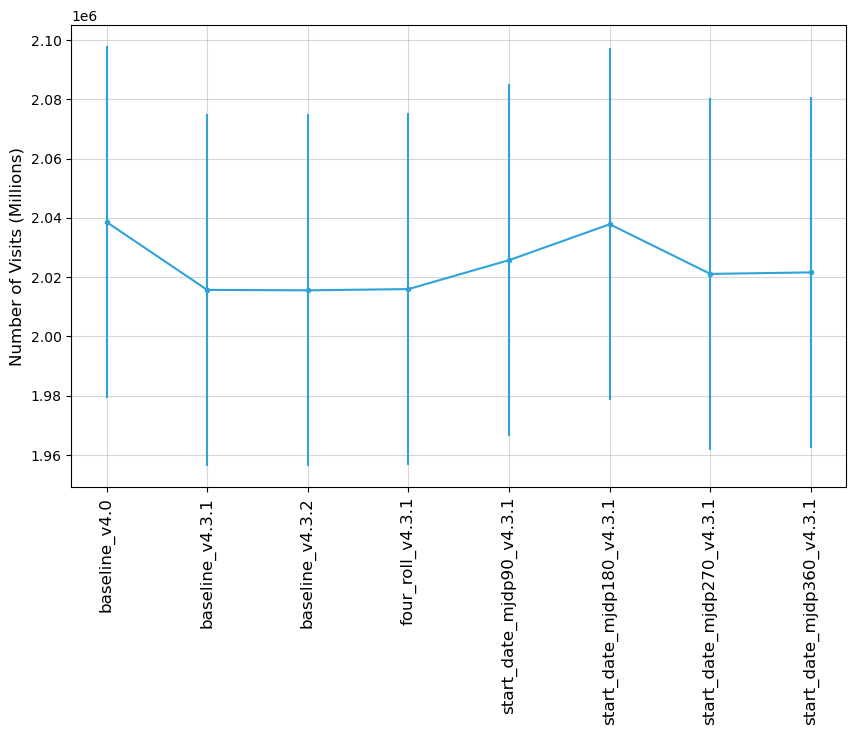

In [13]:
# How did the overall number of visits change for each simulation baseline?  Note some simulations include more shorter visits, and this will be reflected in these numbers.

cols = [m for m in summaries if "Nvisits" in m and "UniSlicer" in m and 'All' in m]
cols

fig, ax = maf.plot_run_metric_uncert(summaries.loc[runs, cols],
                                 dev[cols],
                                 run_label_map=rdict)
ax.set_ylabel(f"Number of Visits (Millions)", fontsize='large')
leg = ax.get_legend()
leg.remove()
fig.savefig(os.path.join(outdir, 'total_nvisits'+ '.png'), format='png')

### SCOC subsets
<a id='SCOC'></a>
A high level overview in a mesh grid, to compare many metrics quickly but without details. 

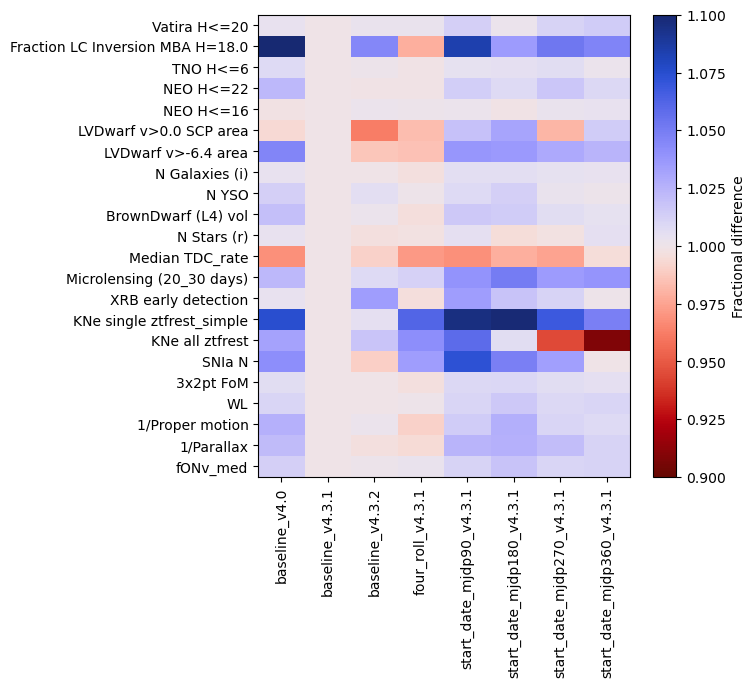

In [14]:
# What about the SCOC high-level overview? 

msub = metrics.loc['SCOC']

fig, ax = maf.plot_run_metric_mesh(summaries.loc[runs, msub['metric']], 
                     baseline_run=baseline,
                     metric_subset=msub,
                        metric_label_map=msub['short_name'],
                        run_label_map=rdict,
                                   color_range=0.2,
                      )
fig.savefig(os.path.join(outdir, 'scoc_grid'+ '.png'), format='png')

['baseline_v4.0_10yrs', 'baseline_v4.3.1_10yrs', 'baseline_v4.3.2_10yrs', 'four_roll_v4.3.1_10yrs', 'start_date_mjdp90_v4.3.1_10yrs', 'start_date_mjdp180_v4.3.1_10yrs', 'start_date_mjdp270_v4.3.1_10yrs', 'start_date_mjdp360_v4.3.1_10yrs']


metric,SNIa N,KNe all ztfrest,KNe single ztfrest_simple,XRB early detection,Microlensing (20_30 days),Median TDC_rate,NEO H<=16,NEO H<=22,TNO H<=6,Fraction LC Inversion MBA H=18.0,Vatira H<=20
run,,,,,,,,,,,
baseline_v4.0_10yrs,1.041620,1.032787,1.074785,1.003505,1.022924,0.968491,0.998328,1.022719,1.007908,1.108865,1.003804
baseline_v4.3.1_10yrs,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
baseline_v4.3.2_10yrs,0.989627,1.017674,1.005199,1.035053,1.007828,0.990137,1.001880,0.998700,1.000828,1.045101,1.002712
four_roll_v4.3.1_10yrs,1.034645,1.041752,1.061988,0.995493,1.012021,0.971425,1.001254,0.999214,0.999005,0.978227,1.002547
start_date_mjdp90_v4.3.1_10yrs,1.073093,1.058914,1.095781,1.035053,1.039419,0.968621,1.001880,1.013360,1.004047,1.083981,1.012567
start_date_mjdp180_v4.3.1_10yrs,1.049191,1.006404,1.098580,1.018528,1.050042,0.978577,0.998955,1.007961,1.005317,1.035770,1.001608
start_date_mjdp270_v4.3.1_10yrs,1.034025,0.943904,1.068386,1.011517,1.035225,0.974700,1.002716,1.016443,1.006309,1.052877,1.011384
start_date_mjdp360_v4.3.1_10yrs,0.999897,0.908299,1.048990,1.000501,1.038580,0.995291,1.003761,1.008824,1.002007,1.046656,1.014548


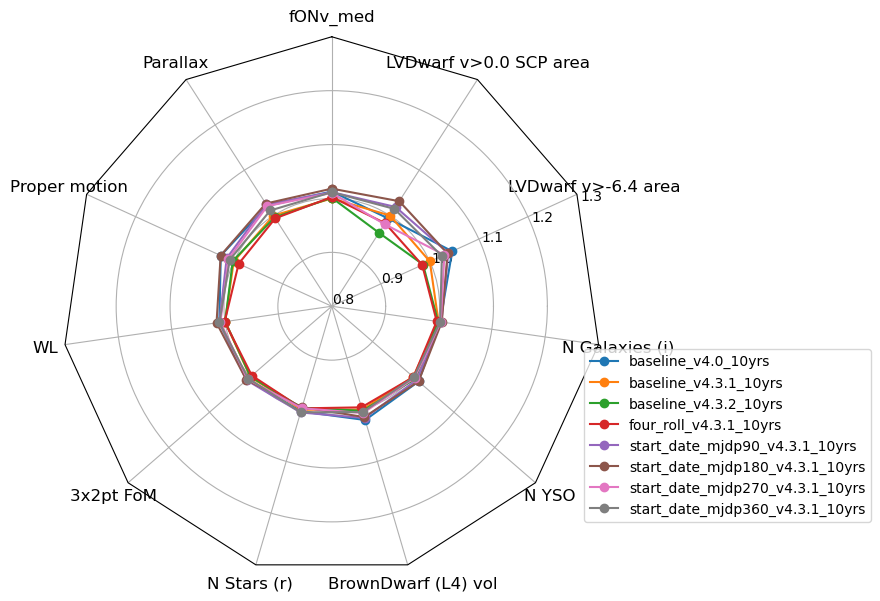

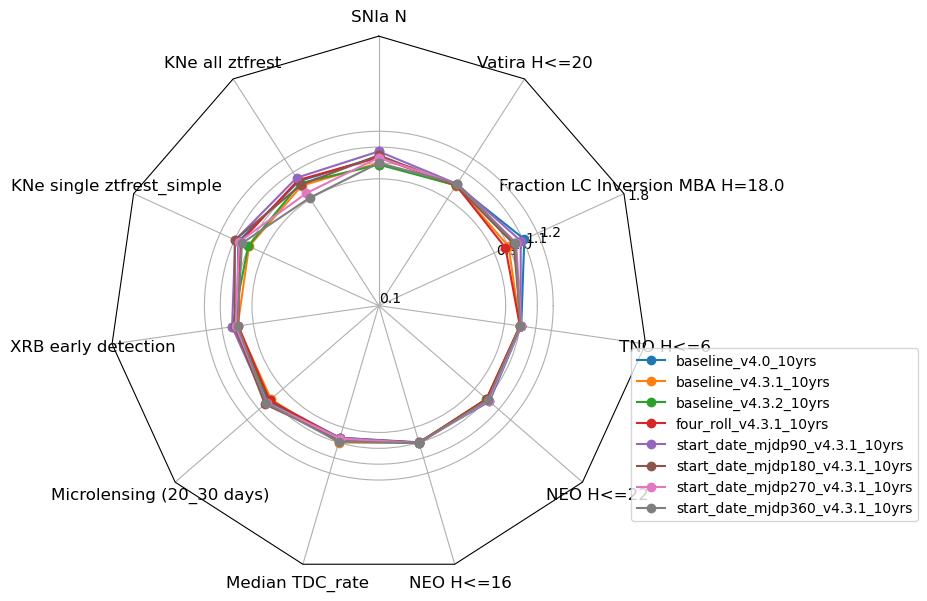

In [15]:
# And some classic 'radar' plots, but only use a subset of the baseline runs
rr = runs
print(rr)

mset = msub

statics = np.array([0, 1, 2, 3, 4, 11, 12, 13, 14, 15, 16])
variable = [i for i in np.arange(0, len(mset)) if i not in statics]

mset_stat = mset.iloc[statics]
mset_var = mset.iloc[variable]

normed = maf.normalize_metric_summaries(baseline,
                                        summaries.loc[rr, mset_stat['metric']],
                                        mset)
normed.columns = normed.columns.map(mset['short_name'])
normed

fig, ax = maf.radar(normed, rgrids=[0.80, 0.9, 1.0, 1.1, 1.2, 1.3], figsize=(8, 8), bbox_to_anchor=[1.5, 0.1])
ax.tick_params(axis='x', labelsize='large')
ax.tick_params(axis='y', labelsize='medium')
fig.set_figwidth(8)
fig.set_figheight(7)


normed = maf.normalize_metric_summaries(baseline,
                                        summaries.loc[rr, mset_var['metric']],
                                        mset)
normed.columns = normed.columns.map(mset['short_name'])
normed

fig, ax = maf.radar(normed, rgrids=[0.10, 0.9, 1.0, 1.1, 1.2, 1.8], figsize=(8, 8), bbox_to_anchor=[1.5, 0.1])
ax.tick_params(axis='x', labelsize='large')
ax.tick_params(axis='y', labelsize='medium')
fig.set_figwidth(8)
fig.set_figheight(7)
normed.loc[rr]

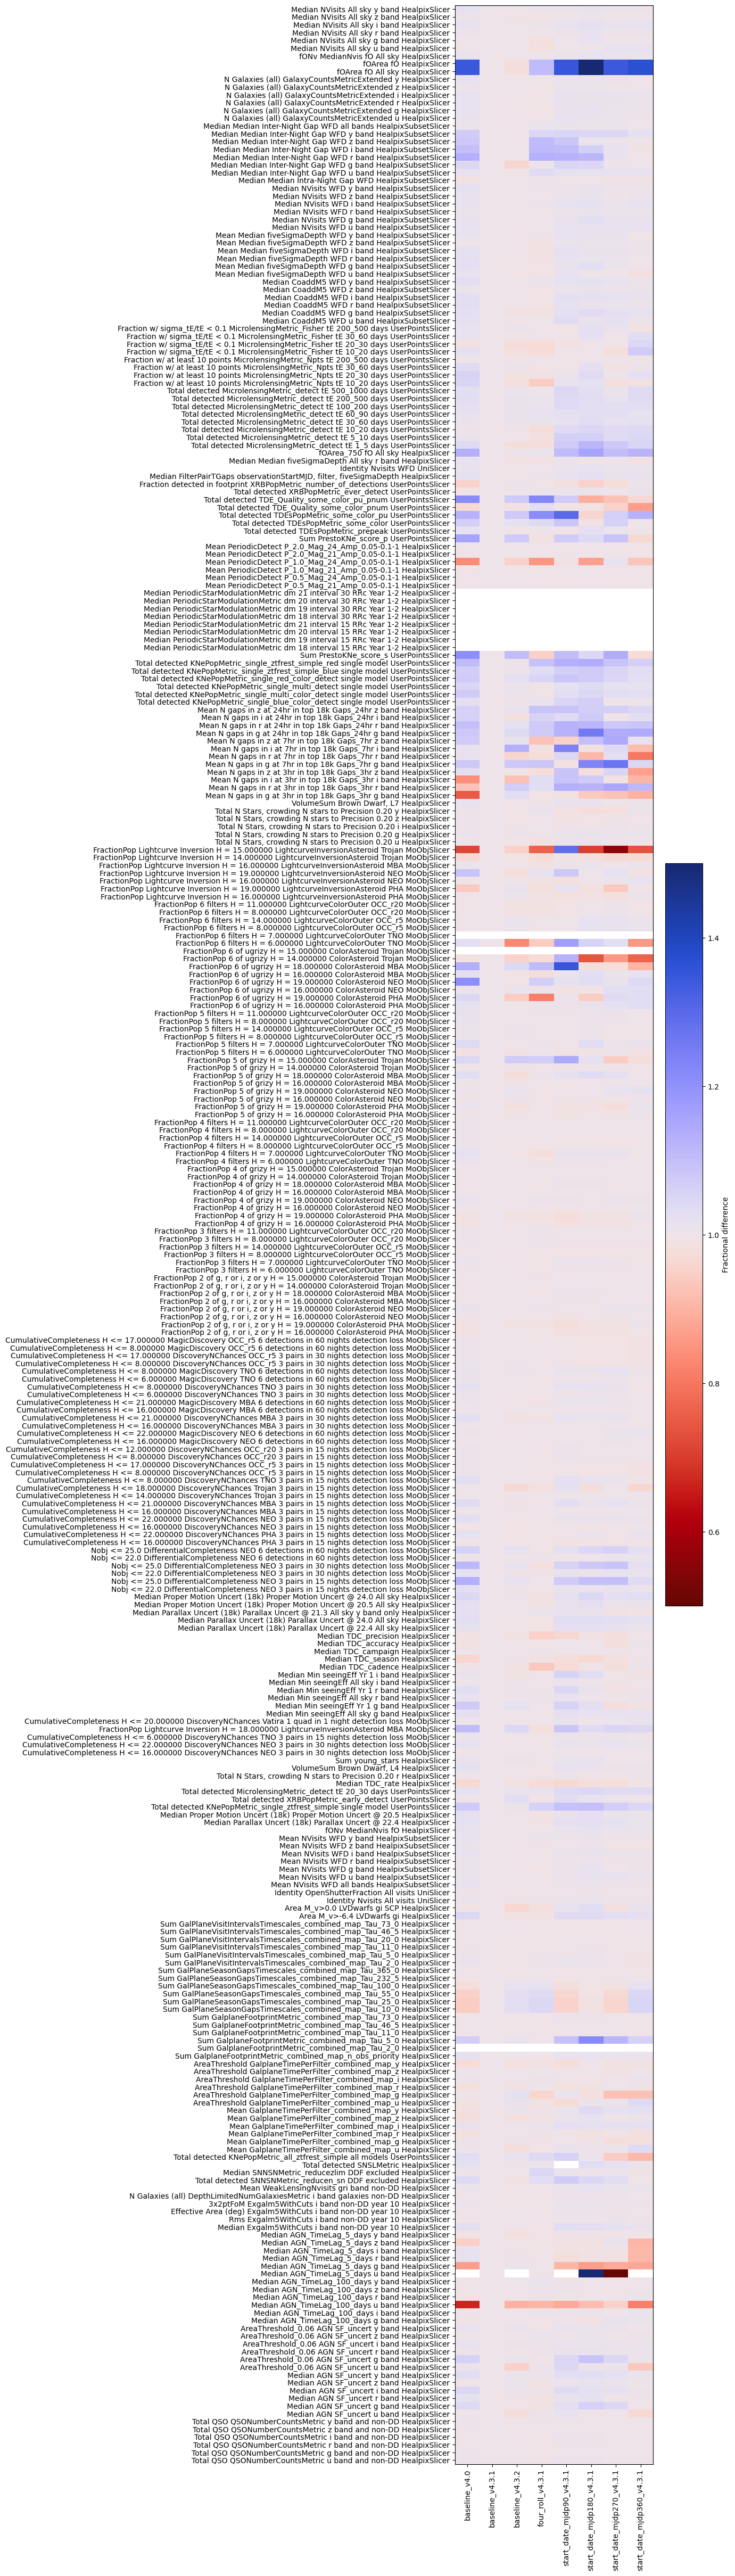

In [16]:
# Plot all the metrics, resulting in a very big and messy plot. Look at overall trends, or for things to investigate further.
non_dd = [m for m in msets if 'DD' not in m]
msub = metrics.loc[non_dd].reset_index(drop=True).drop('style', axis=1).drop('short_name', axis=1)
msub = msub.drop_duplicates().set_index('metric', drop=False, verify_integrity=True)

fig, ax = maf.plot_run_metric_mesh(summaries.loc[runs, msub['metric']], 
                     baseline_run=baseline,
                     metric_subset=msub,
                        #metric_label_map=msub['short_name'],
                        run_label_map=rdict)
#fig.set_figwidth(24)
fig.set_figheight(60)
fig.savefig(os.path.join(outdir, 'all_grid'+ '.png'), format='png')

Now we look at the metrics results for subsets of metrics, looking in more depth (which allows us to include error bars which come from the standard deviation of the metric results in the weather runs.

### SRD
<a id="SRD"></a>
Metrics coming from the Science Requirements Document, the [SRD](ls.st/srd). 

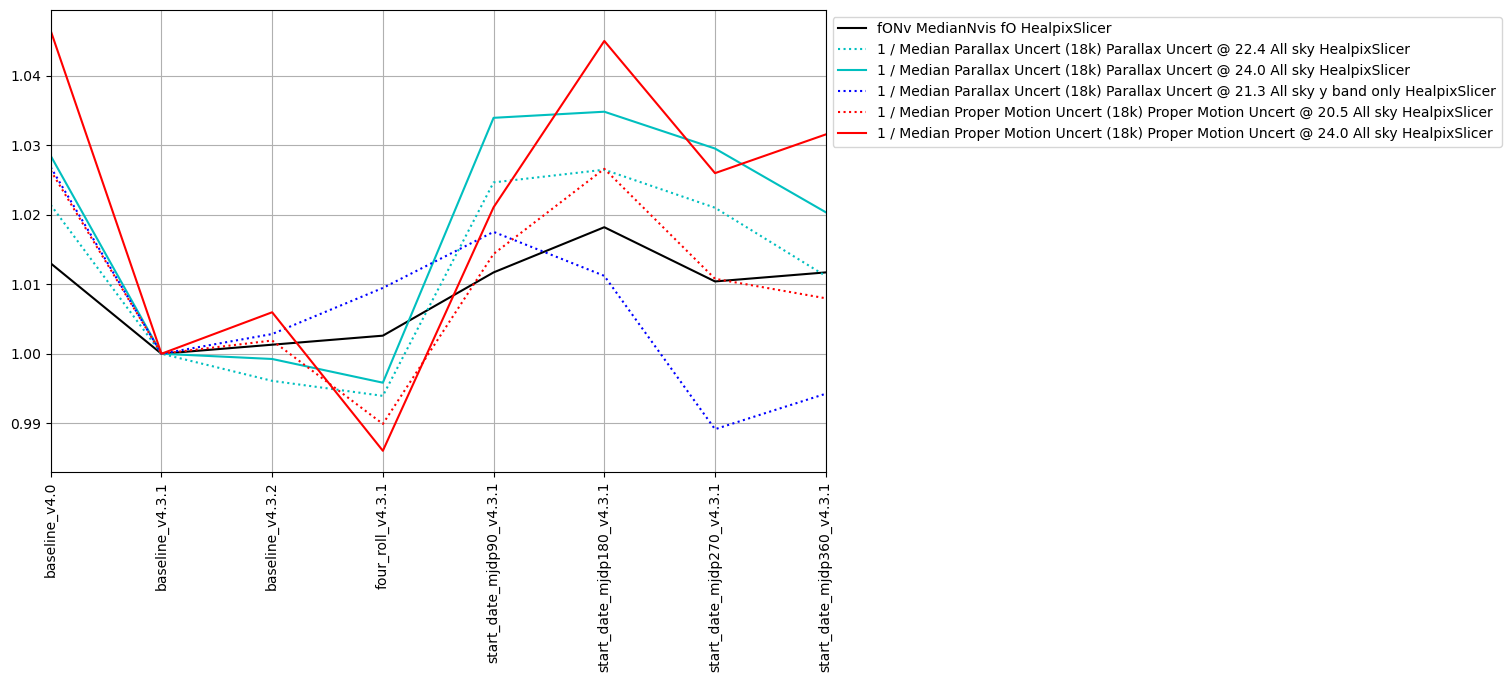

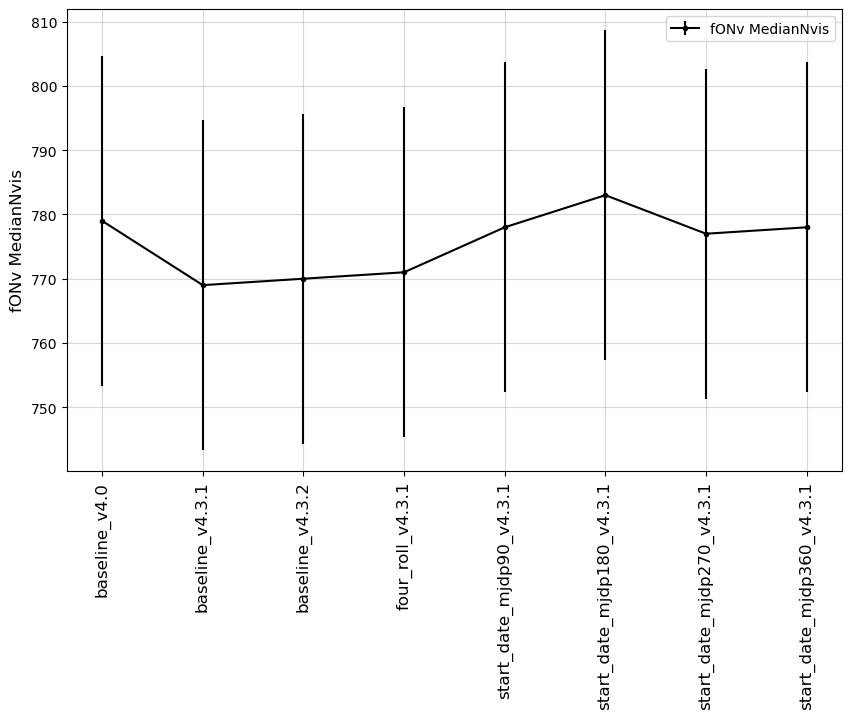

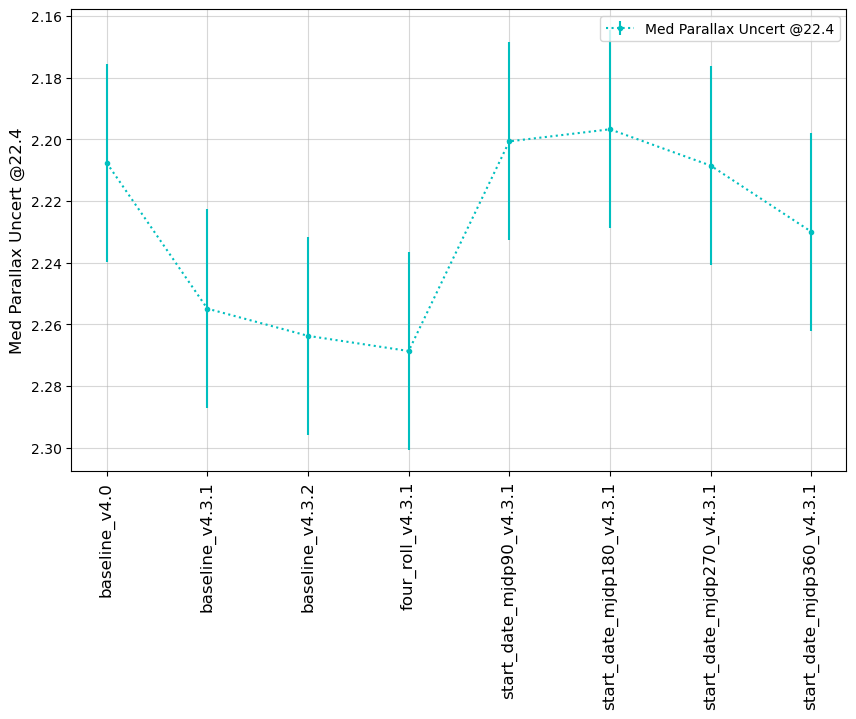

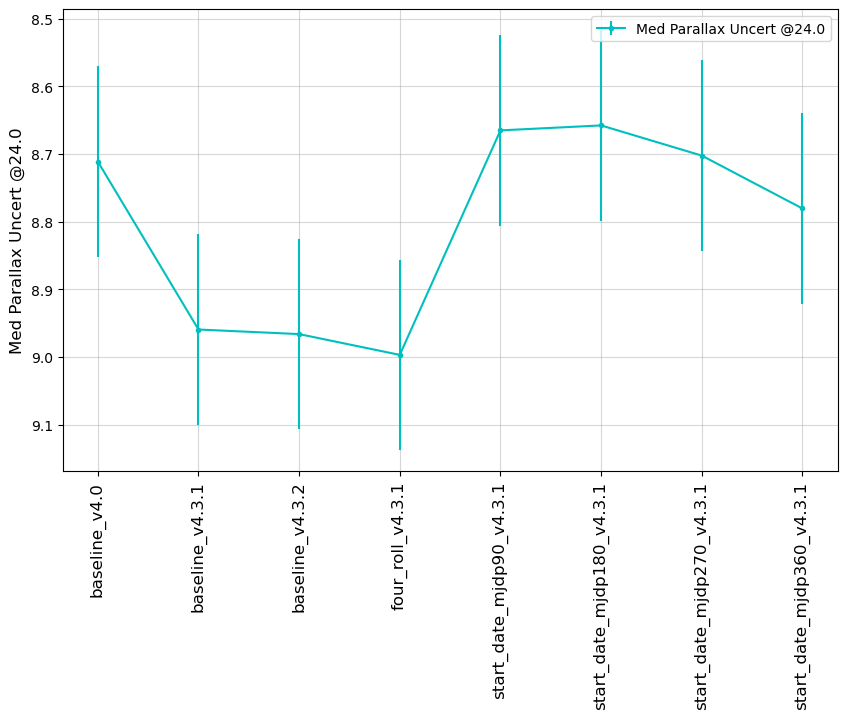

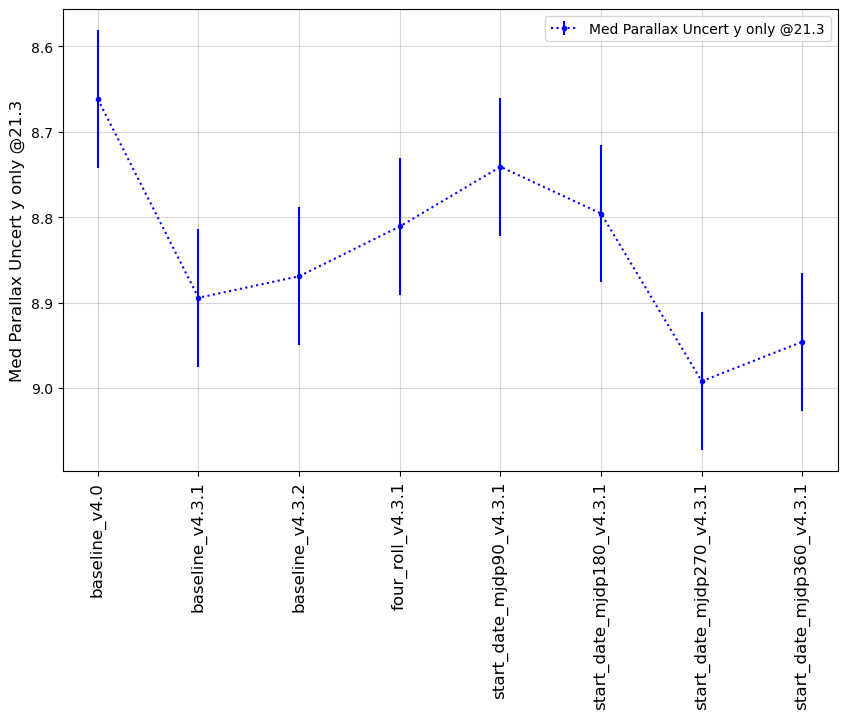

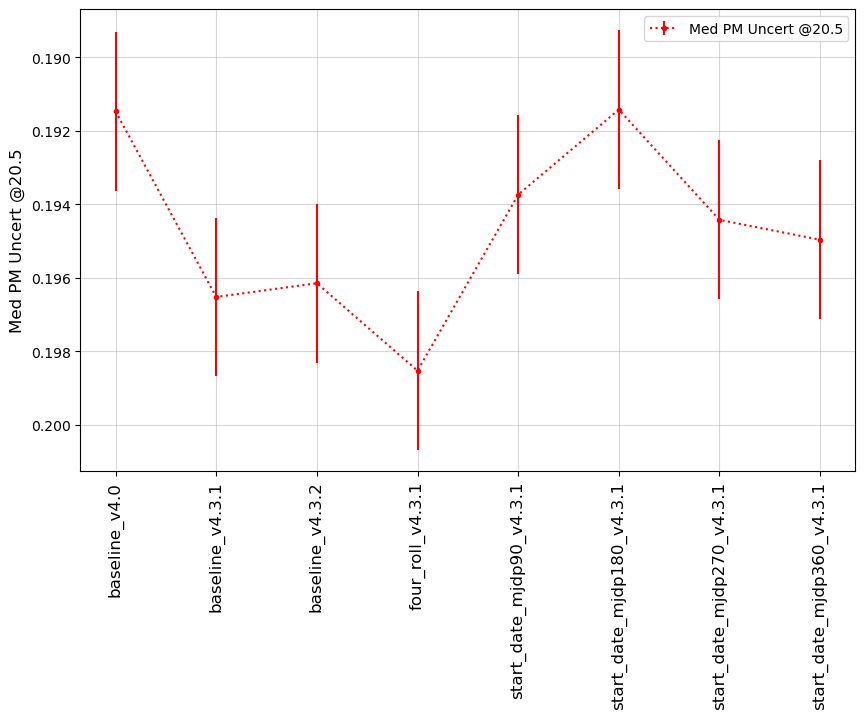

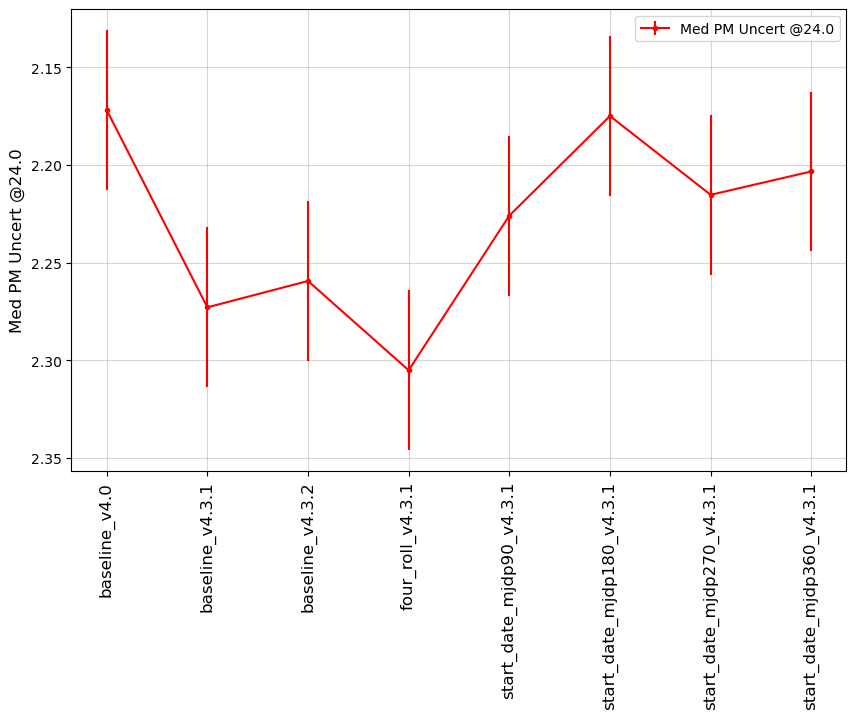

In [17]:
msub = metrics.loc['SRD']

fig, ax = maf.plot_run_metric(summaries.loc[runs, msub['metric']], 
                              baseline_run=baseline, 
                              metric_subset=msub,
                              run_label_map=rdict,
                              horizontal_quantity='run',
                              vertical_quantity='value')

fig, ax = maf.plot_run_metric_uncert(summaries.loc[runs, msub['metric']], 
                                 dev[msub['metric']], 
                                 metric_label_map=msub['short_name'], 
                                 run_label_map=rdict,
                                 metric_subset=msub,)

### DESC WFD
<a id="DESC WFD"></a>
Metrics related to DESC WFD goals. These include both static science and transient science.

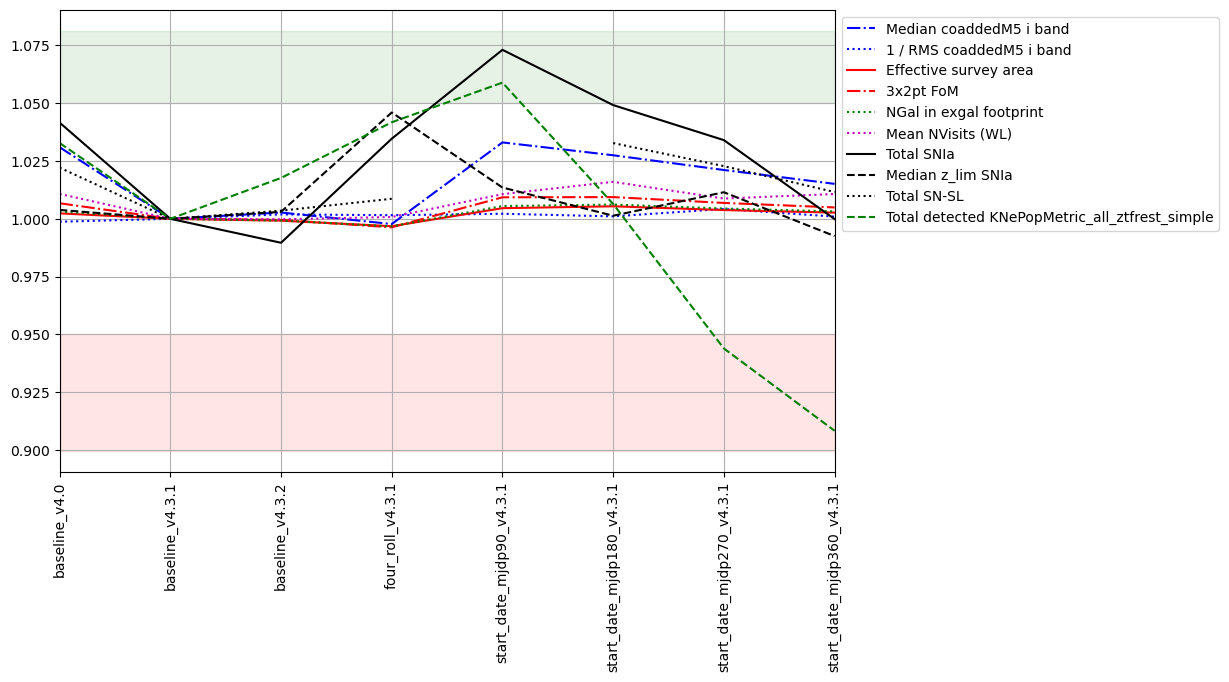

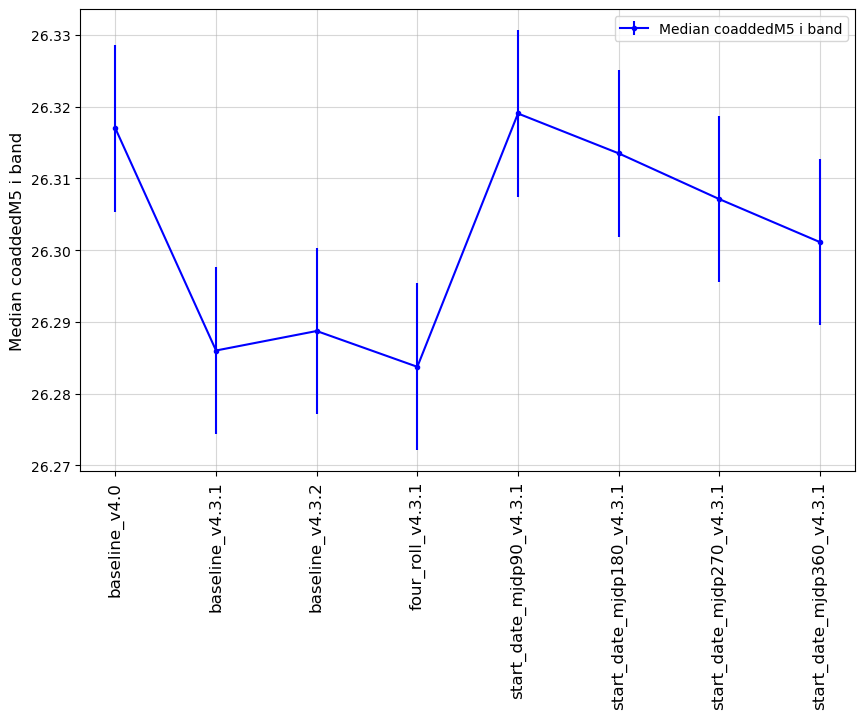

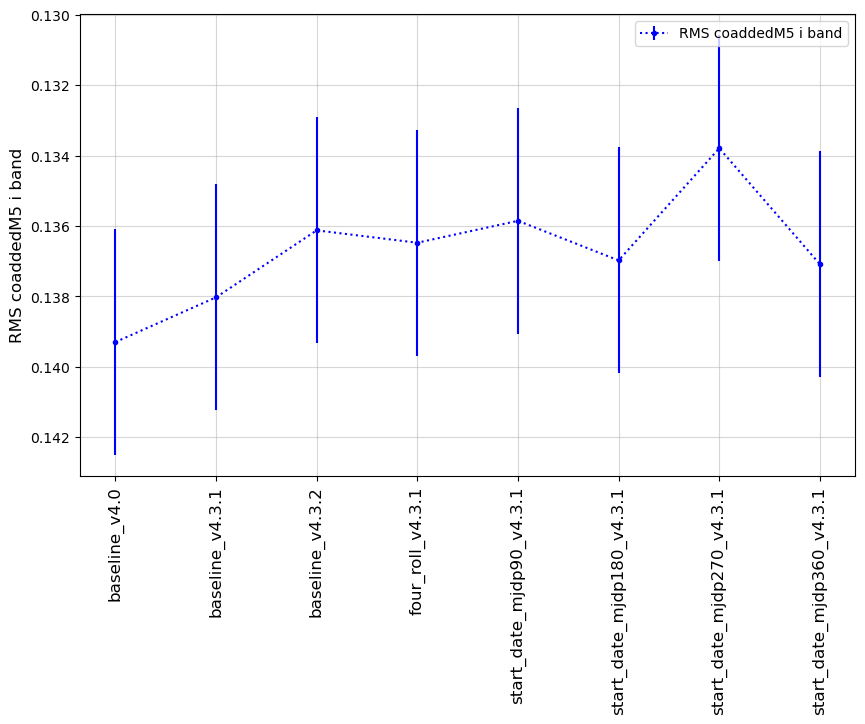

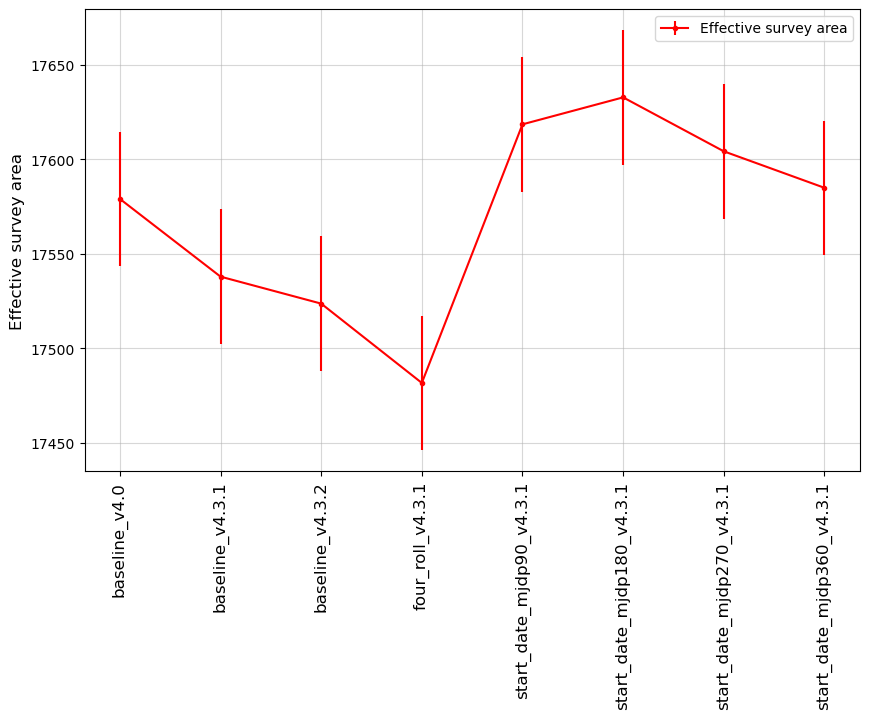

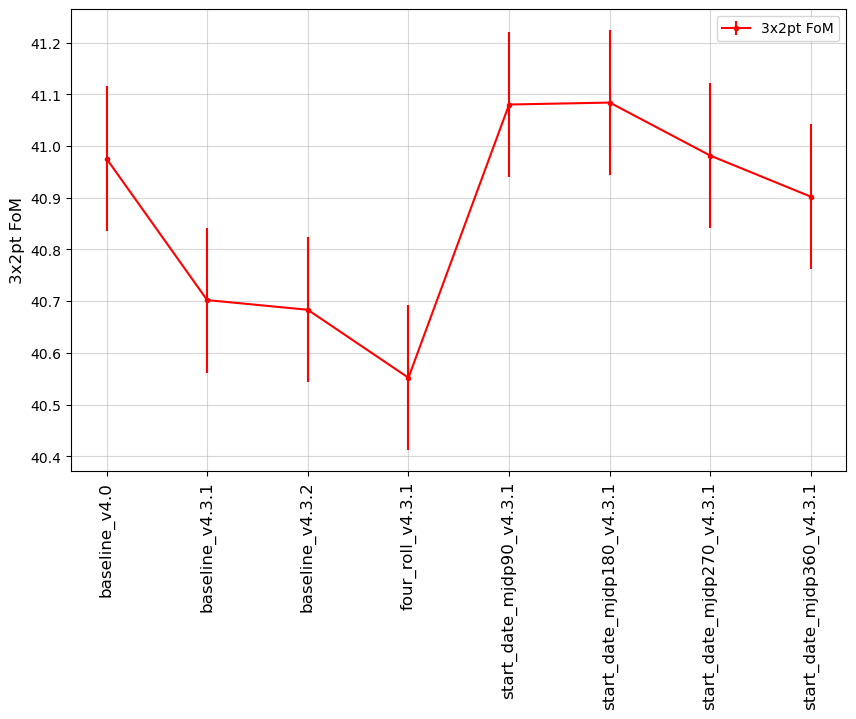

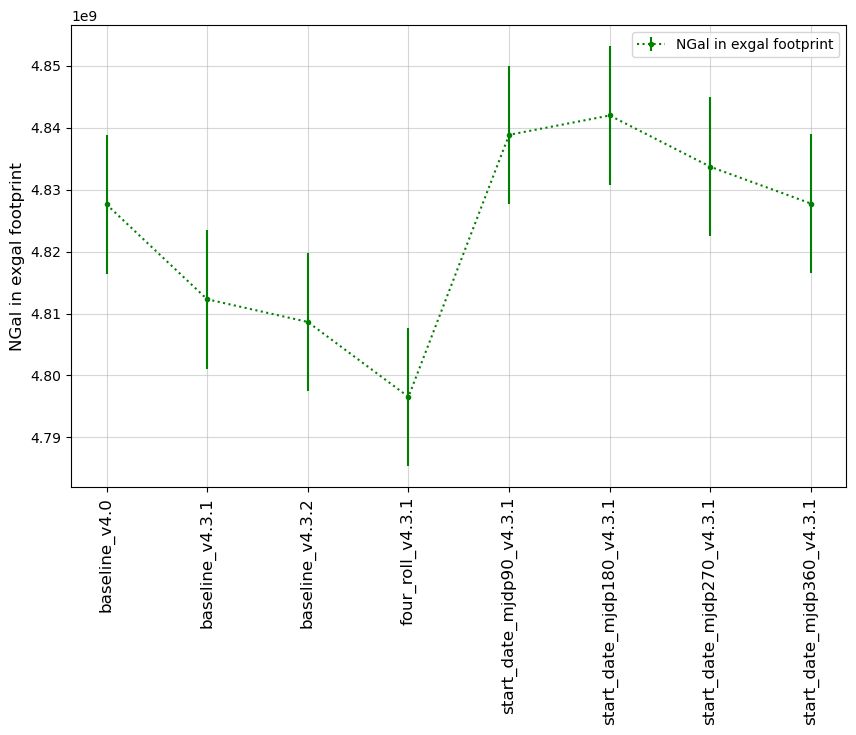

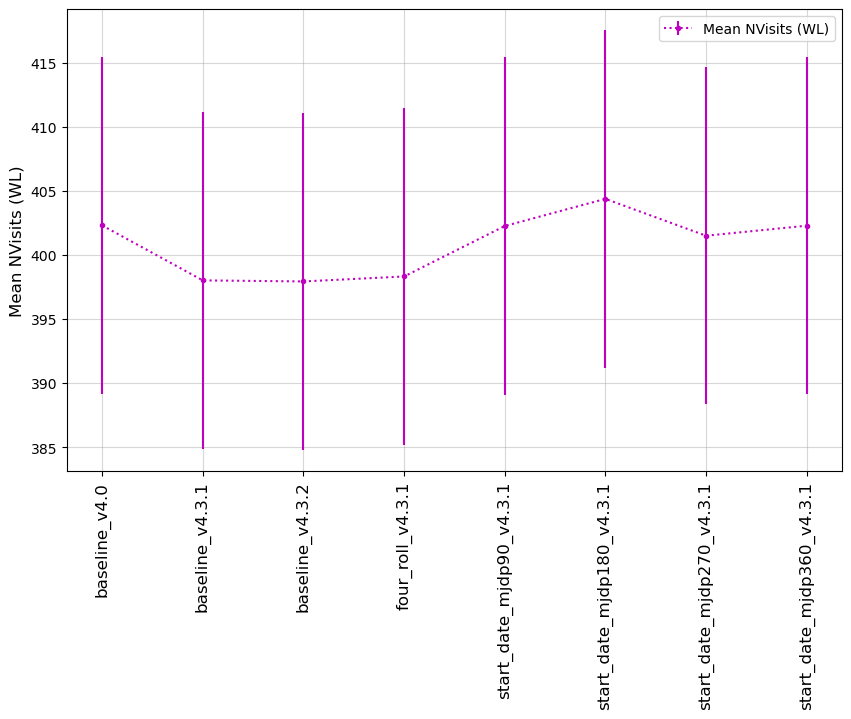

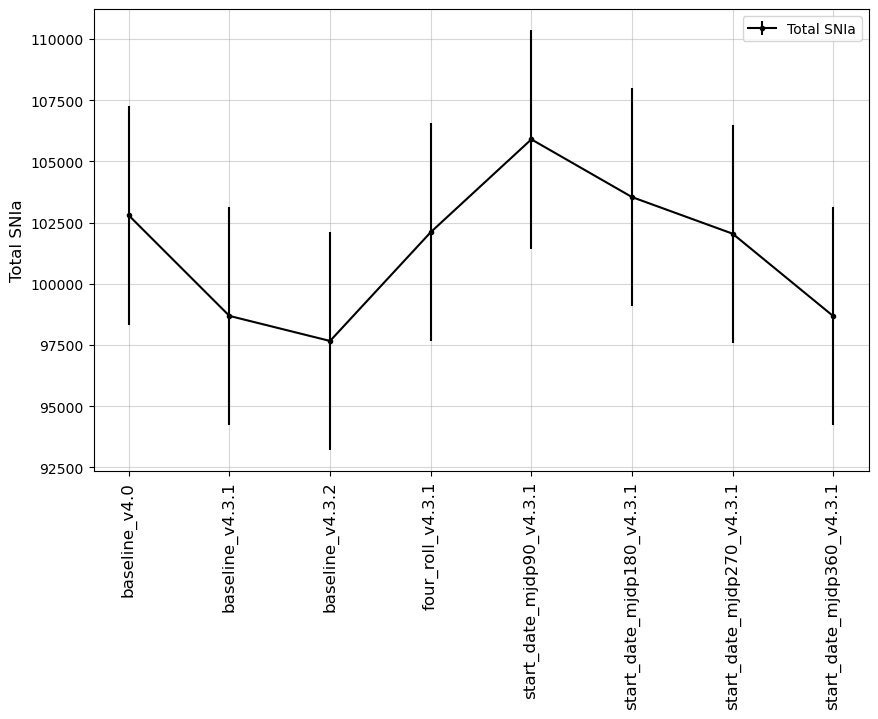

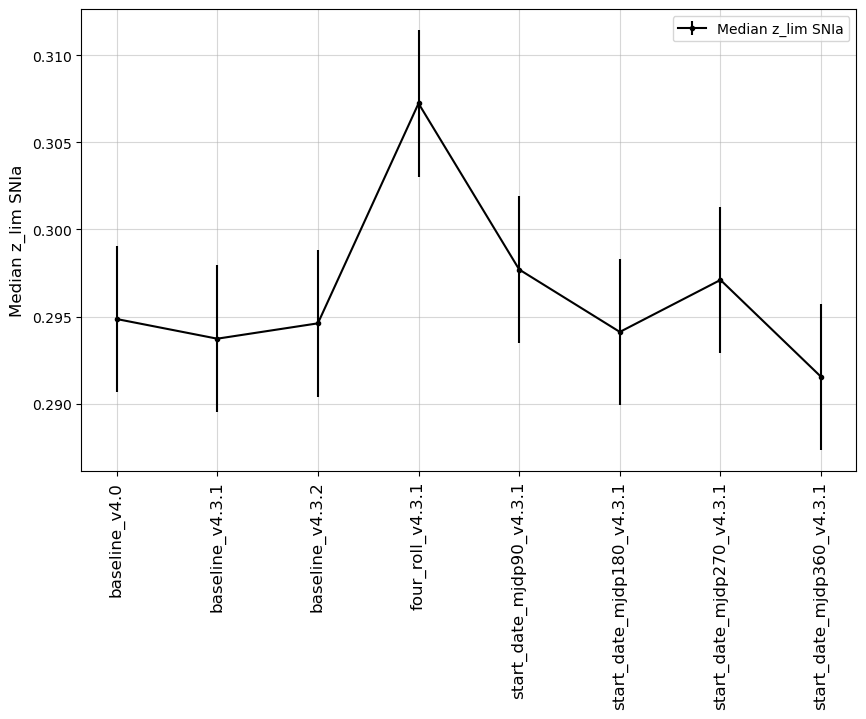

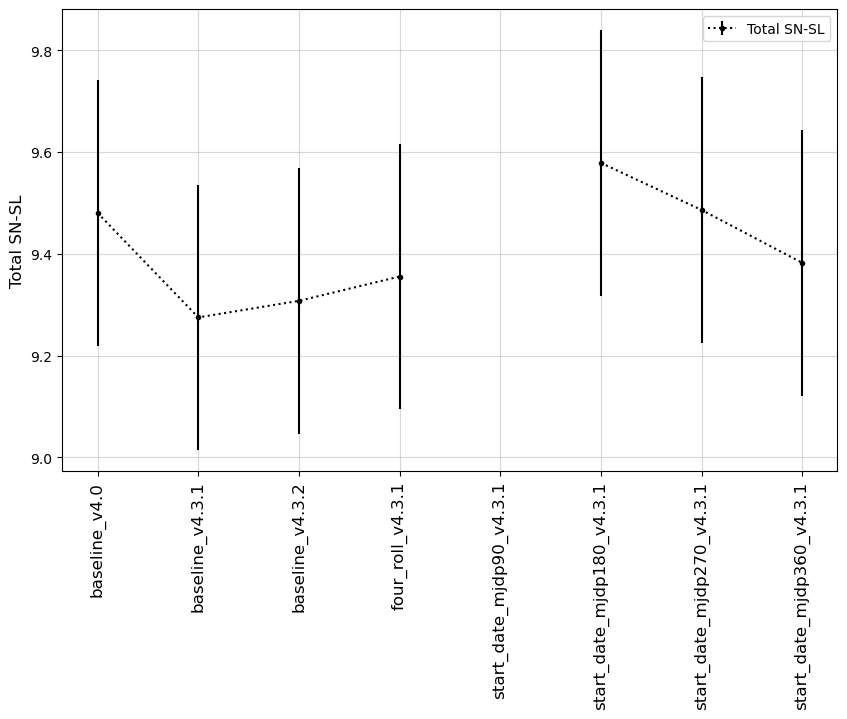

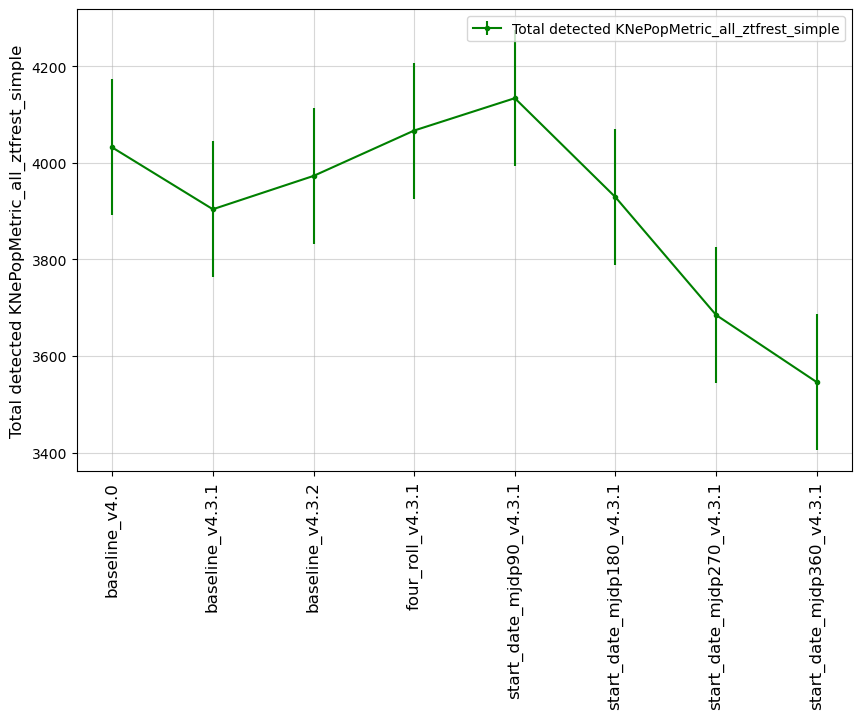

In [18]:
msub = metrics.loc['DESC WFD']

fig, ax = maf.plot_run_metric(summaries.loc[runs, msub['metric']], 
                              baseline_run=baseline, 
                              metric_subset=msub,
                              metric_label_map=msub['short_name'],
                              run_label_map=rdict,
                              horizontal_quantity='run',
                              vertical_quantity='value')

fig, ax = maf.plot_run_metric_uncert(summaries.loc[runs, msub['metric']], 
                                 dev[msub['metric']], 
                                 metric_label_map=msub['short_name'], 
                                 run_label_map=rdict,
                                 metric_subset=msub)

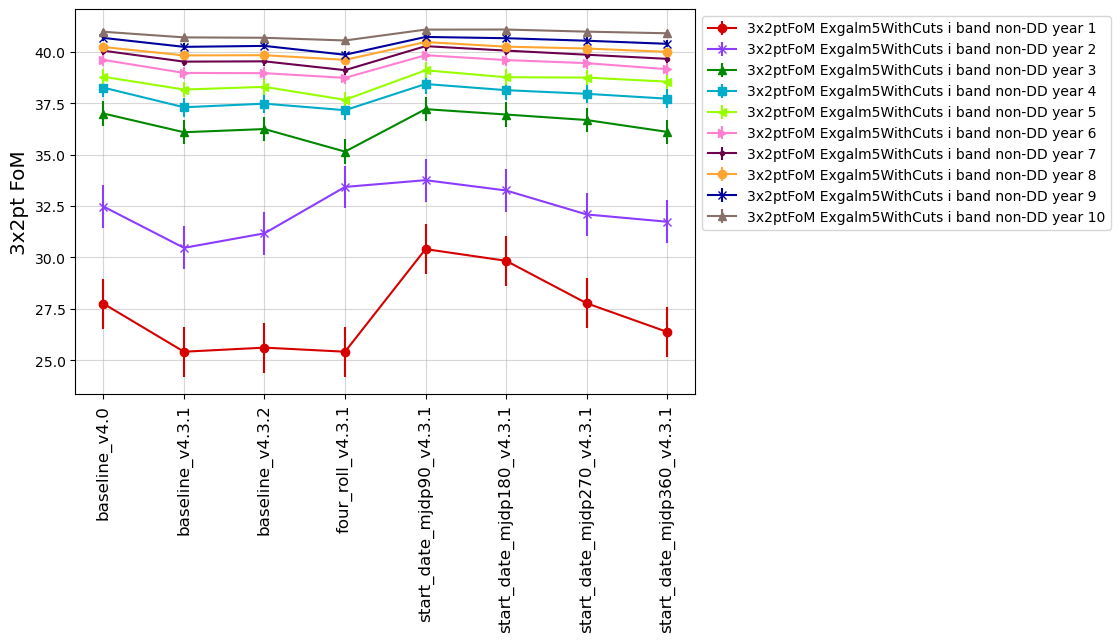

In [19]:
# Compare 3x2pt FOM metrics at individual years, between different simulations.
m1 = []
for yr in range(1, 11):
    m1 += [f'3x2ptFoM Exgalm5WithCuts i band non-DD year {yr} HealpixSlicer']

mset = maf.create_metric_subset('3x2pt', 
                                metrics=m1, 
                                short_name=[m.replace(' HealpixSlicer', '') for m in m1],
                               )
msub = mset.loc['3x2pt']

fig, ax = maf.plot_run_metric_uncert(summaries.loc[runs, msub['metric']], 
                                 dev[msub['metric']], 
                                 metric_label_map=msub['short_name'], 
                                 run_label_map=rdict,
                                 cmap=colorcet.glasbey_bw,
                                 metric_subset=msub,
                                 markers=['o', 'x', '^', 's', '<', '>', '.', ],
                                 sep_plots=False)                                 
ax.set_ylabel("3x2pt FoM", fontsize='x-large')
fig.set_figwidth(8)
fig.set_figheight(5)

### Transient and Variable Stars
<a id="TVS"></a>
Metrics related to Transient and Variable Stars collaboration goals. 

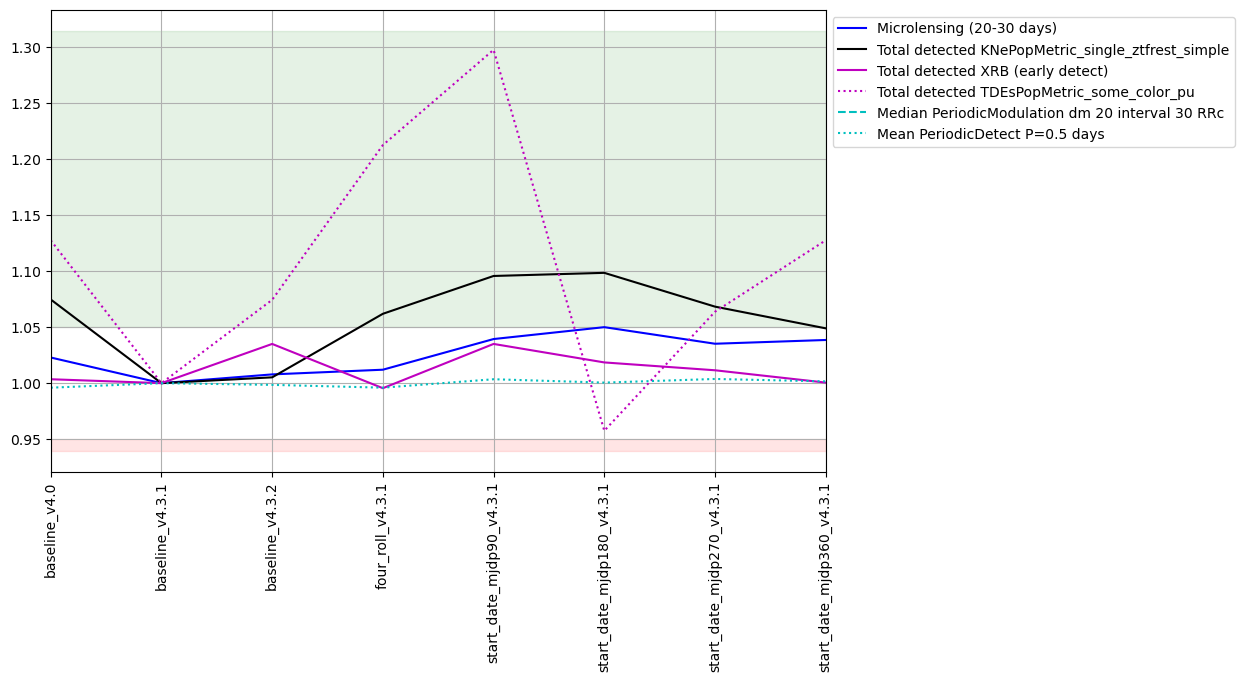

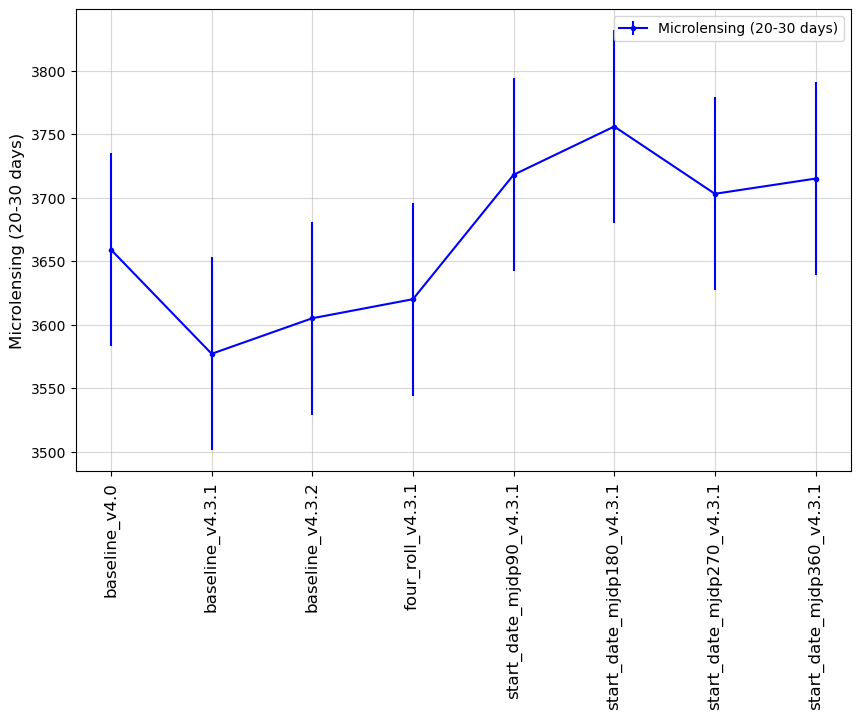

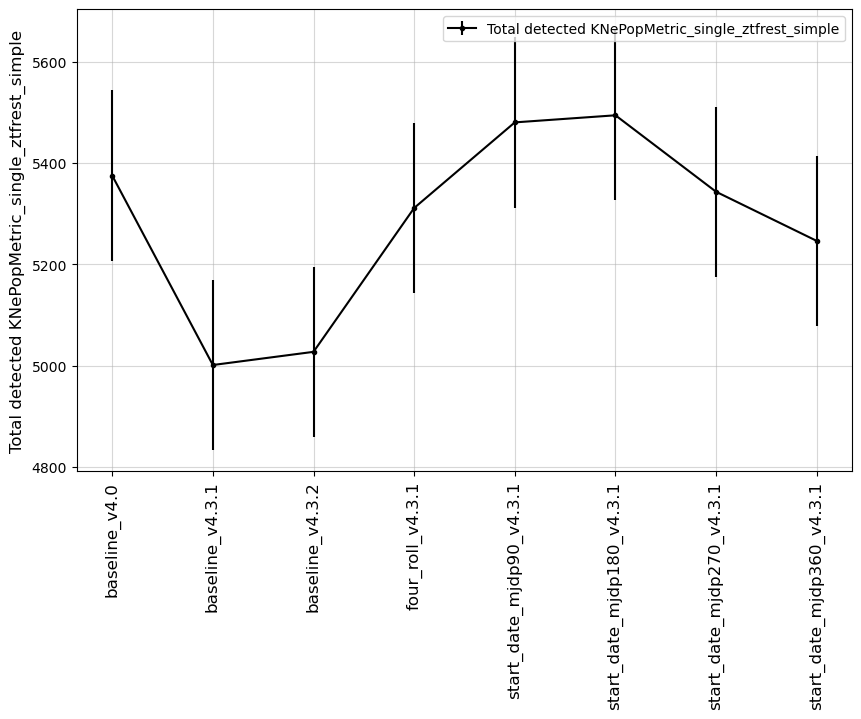

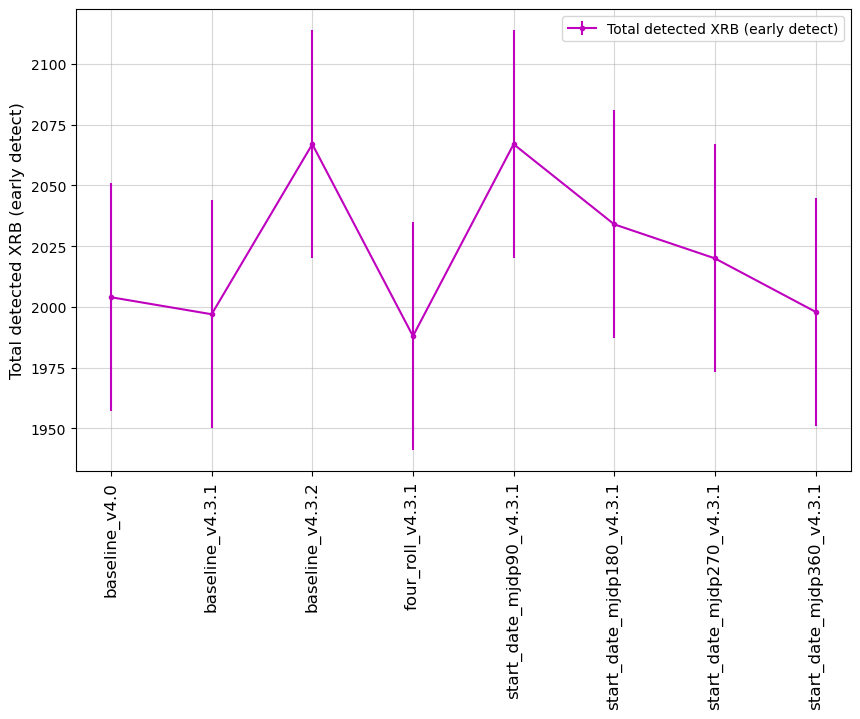

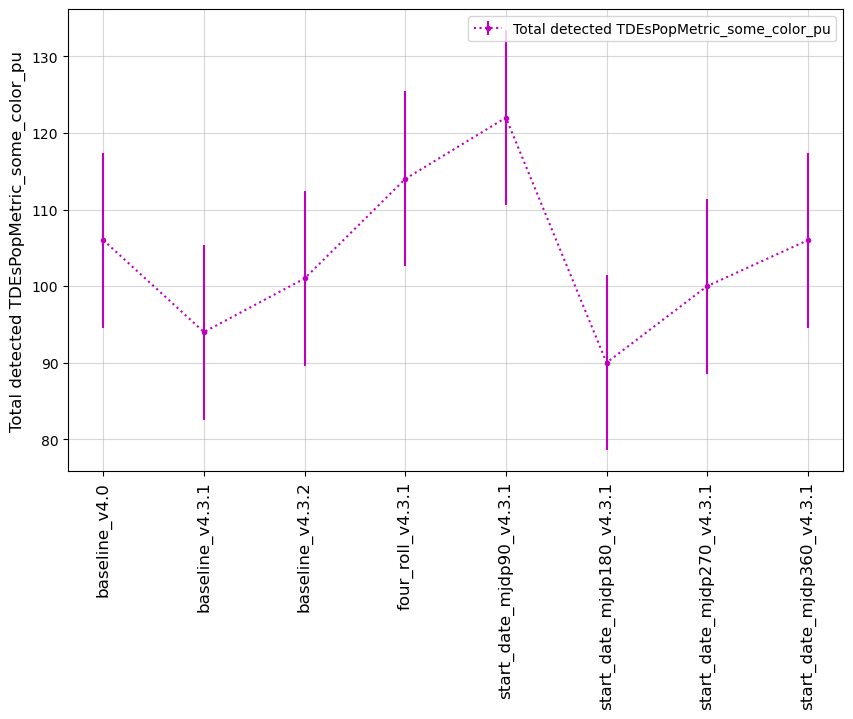

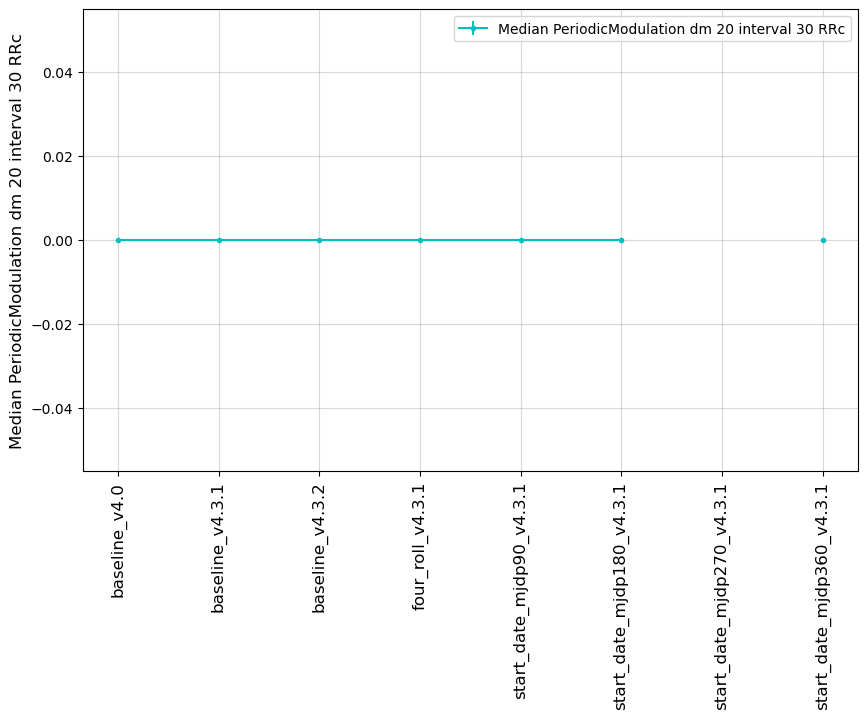

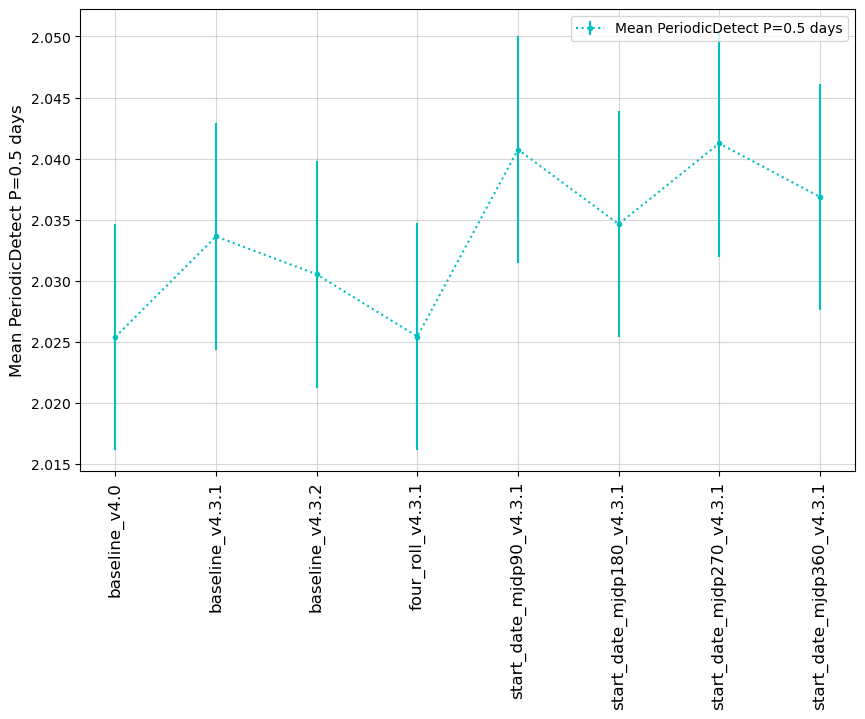

In [20]:
msub = metrics.loc['TVS short']

fig, ax = maf.plot_run_metric(summaries.loc[runs, msub['metric']], 
                              baseline_run=baseline, 
                              metric_subset=msub,
                              metric_label_map=msub['short_name'],
                              run_label_map=rdict,
                              horizontal_quantity='run',
                              vertical_quantity='value')

fig, ax = maf.plot_run_metric_uncert(summaries.loc[runs, msub['metric']], 
                                 dev[msub['metric']], 
                                 metric_label_map=msub['short_name'], 
                                 run_label_map=rdict,
                                 metric_subset=msub)

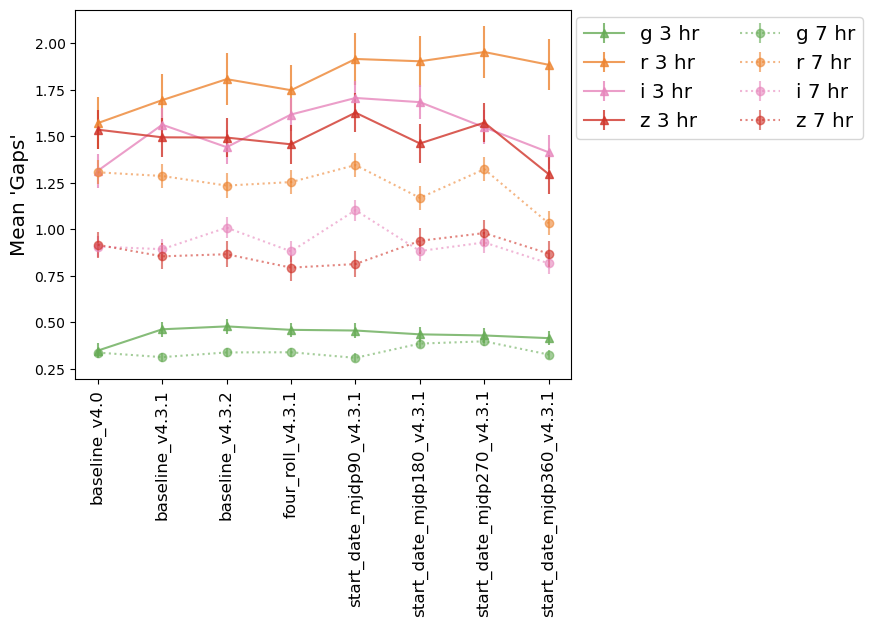

In [21]:
# Time Gaps metric 

fig, ax = plt.subplots()
mset = metrics.loc['TVS Gaps'][0:8]


markers = ['o', 's', '*', '<', '^', 'v', '*', '>', '.', 'X']
j = 0
for i, mm in mset.iterrows():
    m = mm['metric']
    ff = mm['short_name'].split('in ')[-1].split(' at')[0]
    #marker= markers[j]
    marker = 'o'
    if '3' in m:
        marker = '^'
        linestyle='-'
        alpha=0.8
        label=f"{ff} 3 hr"
    if '7' in m:
        marker = 'o'
        linestyle=':'
        alpha=0.6
        label =f"{ff} 7 hr"
    j += 1
    ax.errorbar(list(rdict.values()), summaries.loc[runs, m], yerr=dev[m], 
                color=filter_rgb_map[ff], alpha=alpha, marker=marker, linestyle=linestyle, label=label)
plt.legend(loc=(1.01, 0.65), fontsize='x-large', ncols=2)
ax.set_ylabel("Mean 'Gaps'", fontsize='x-large')
ax.tick_params(axis='x', labelrotation = 90, labelsize='large')
fig.savefig(os.path.join(outdir, 'tgaps' + '.png'), format='png')

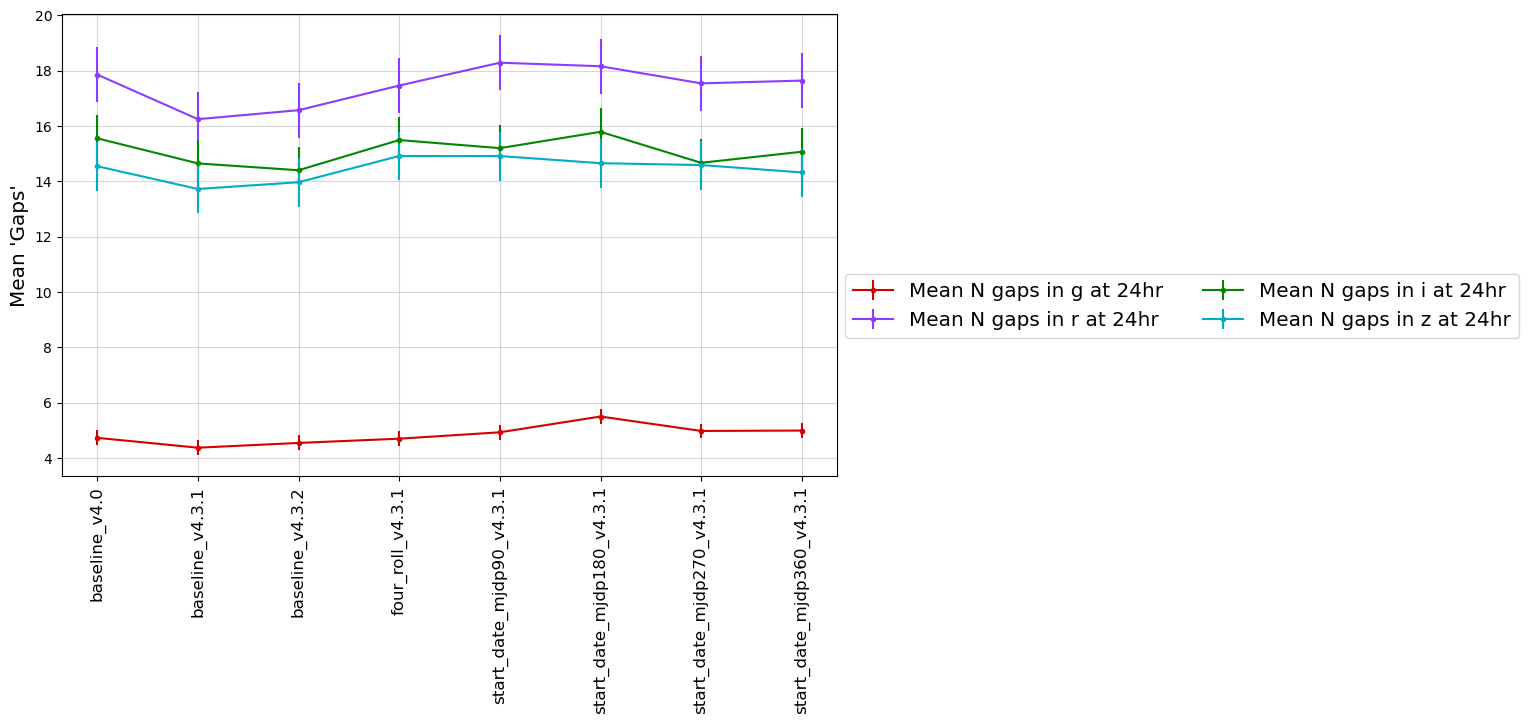

In [22]:
msub = metrics.loc['TVS Gaps'][8:12]

fig, ax = maf.plot_run_metric_uncert(summaries.loc[runs, msub['metric']], 
                                 dev[msub['metric']], 
                                 metric_label_map=msub['short_name'], 
                                 run_label_map=rdict,
                                 cmap=colorcet.glasbey_dark,
                                 metric_subset=msub, sep_plots=False)
plt.legend(loc=(1.01, 0.3), fontsize='x-large', ncols=2)
ax.set_ylabel("Mean 'Gaps'", fontsize='x-large')
ax.tick_params(axis='x', labelrotation = 90, labelsize='large')

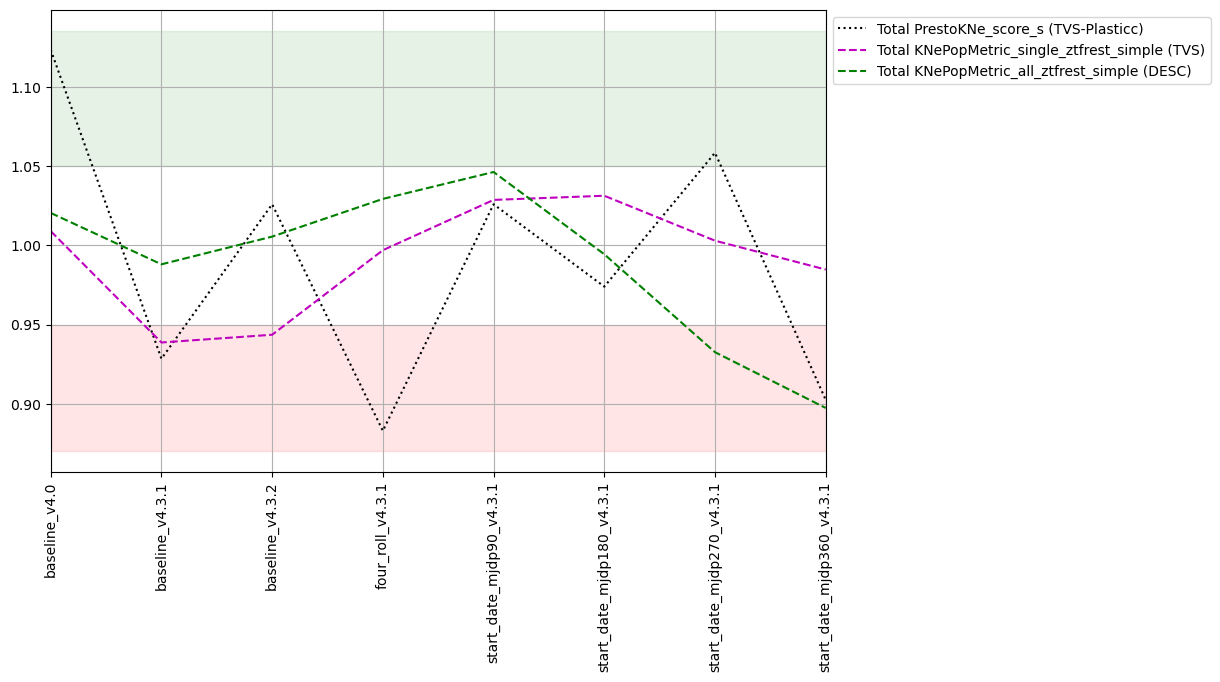

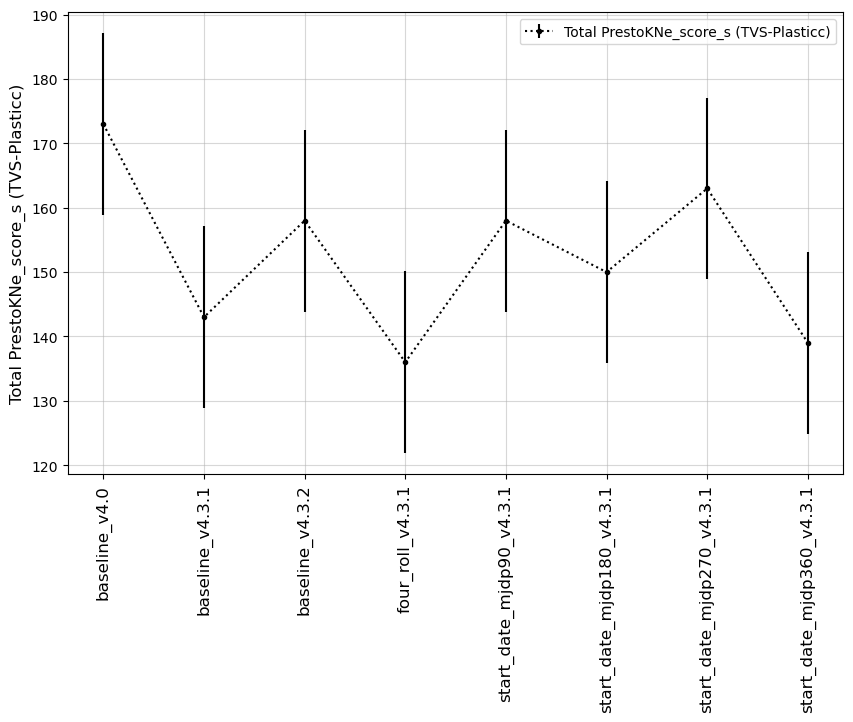

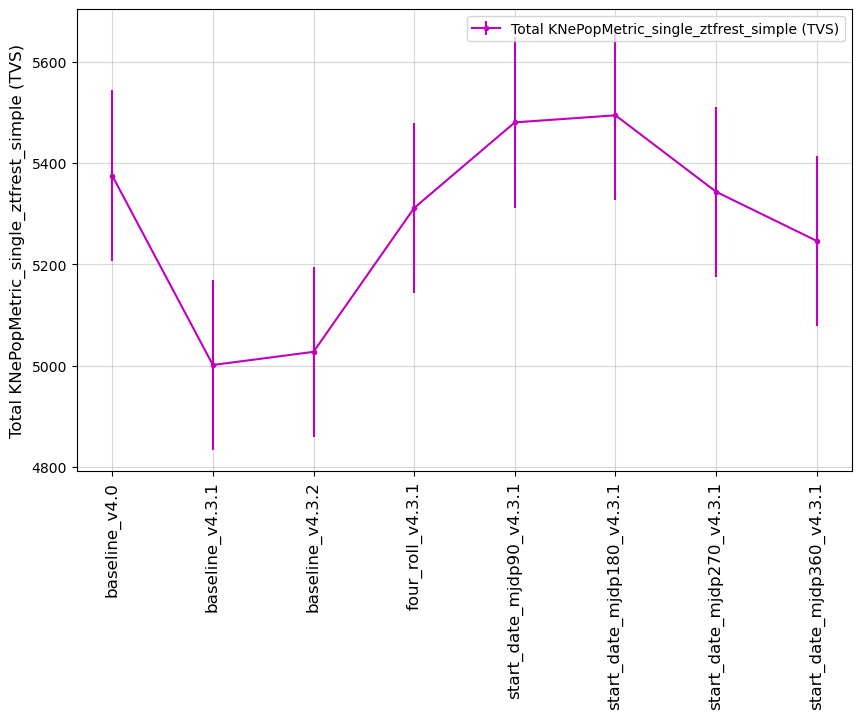

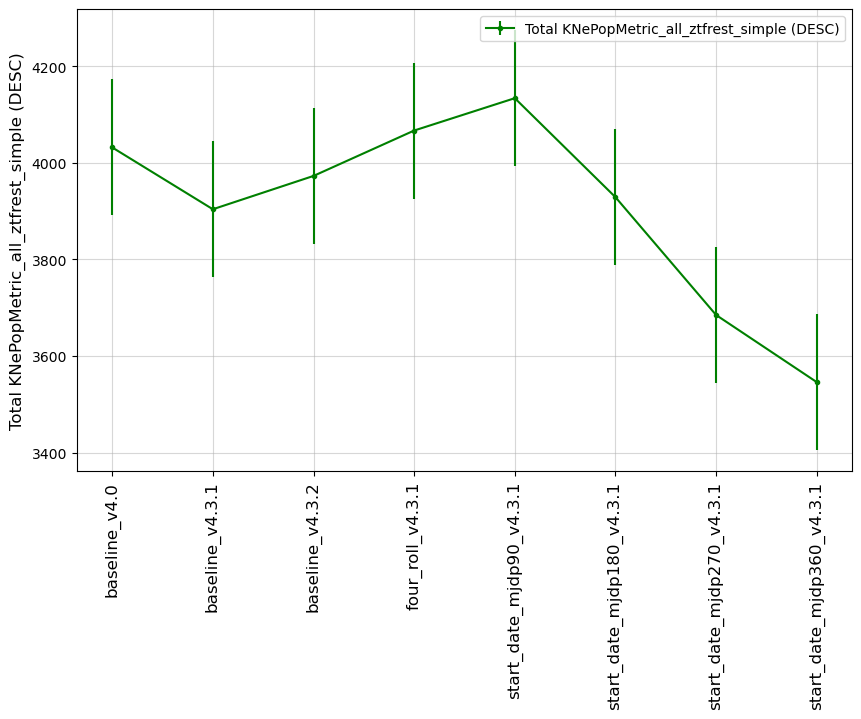

In [23]:
msub = metrics.loc['TVS KNe short']

fig, ax = maf.plot_run_metric(summaries.loc[runs, msub['metric']], 
                              baseline_run=runs,
                              metric_subset=msub,
                              metric_label_map=msub['short_name'],
                              run_label_map=rdict,
                              horizontal_quantity='run',
                              vertical_quantity='value')

fig, ax = maf.plot_run_metric_uncert(summaries.loc[runs, msub['metric']], 
                                 dev[msub['metric']], 
                                 metric_label_map=msub['short_name'], 
                                 run_label_map=rdict,
                                 metric_subset=msub)

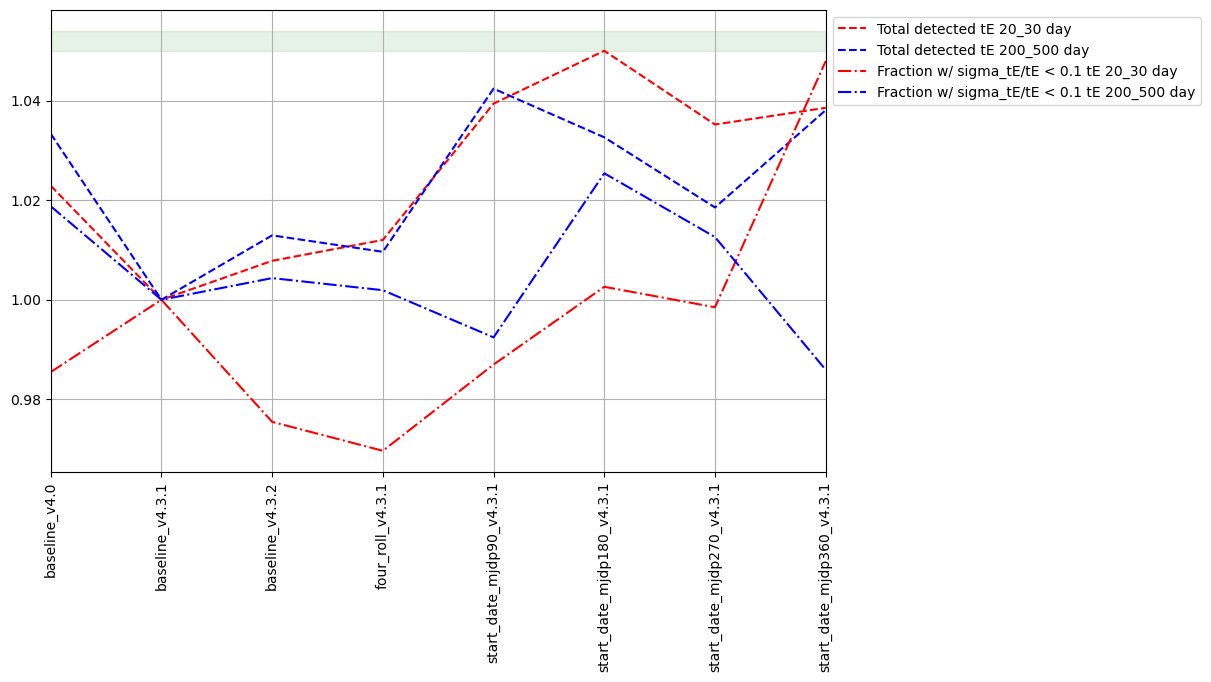

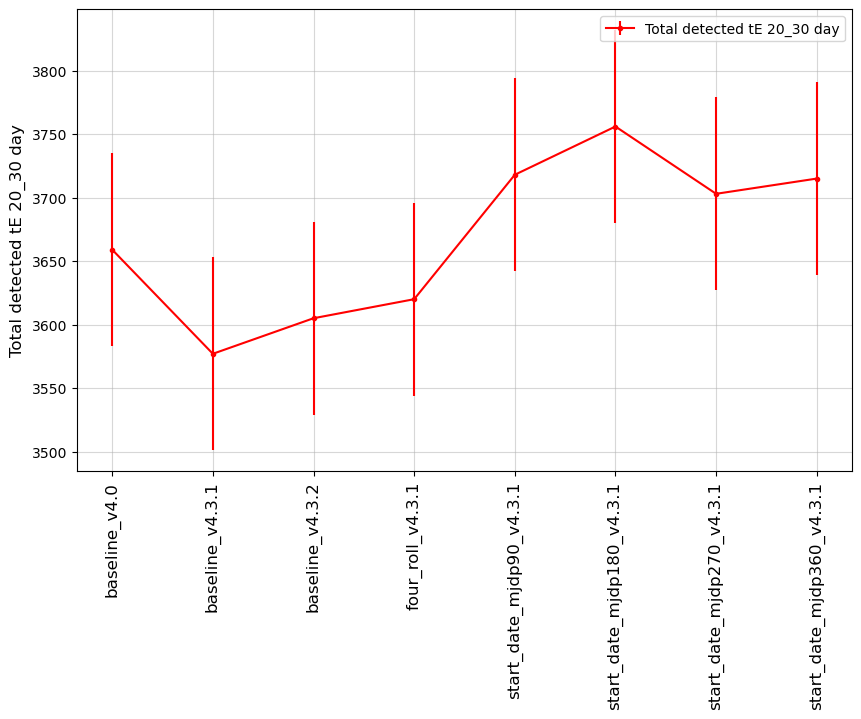

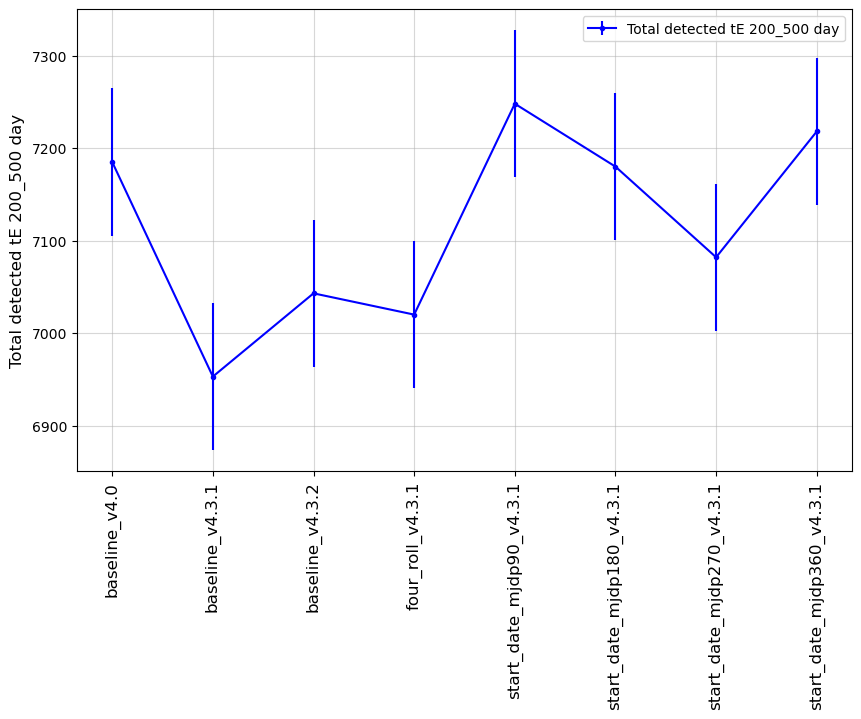

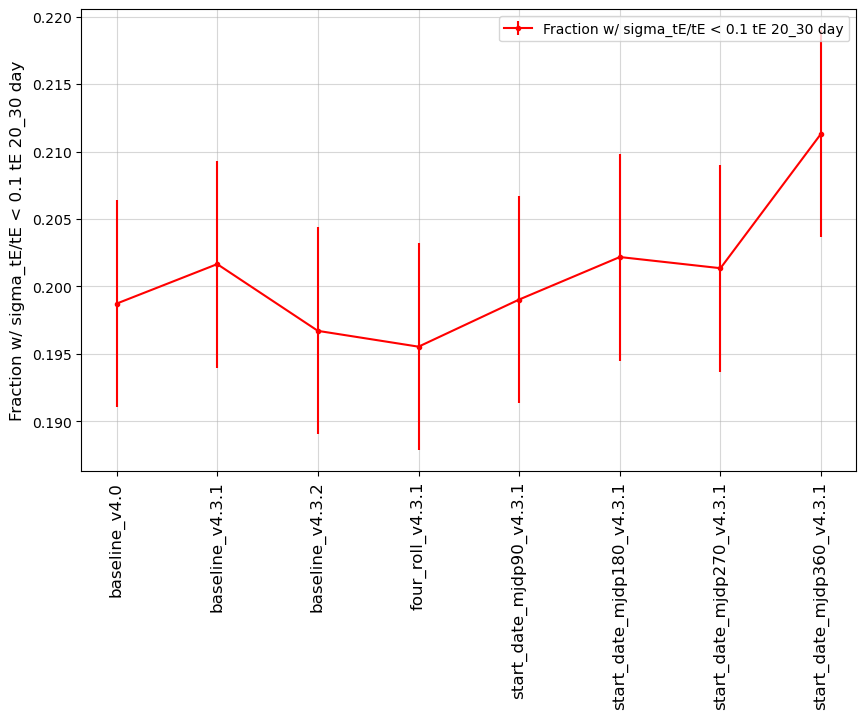

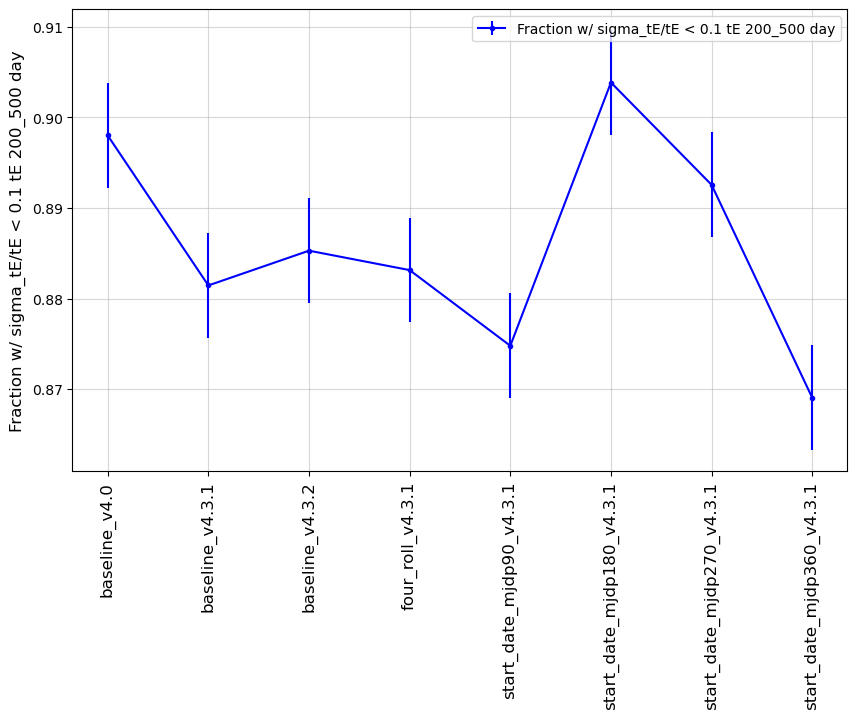

In [ ]:
msub = metrics.loc['TVS microlensing short']

fig, ax = maf.plot_run_metric(summaries.loc[runs, msub['metric']], 
                              baseline_run=baseline, 
                              metric_subset=msub,
                              metric_label_map=msub['short_name'],
                              run_label_map=rdict,
                              horizontal_quantity='run',
                              vertical_quantity='value')

fig, ax = maf.plot_run_metric_uncert(summaries.loc[runs, msub['metric']], 
                                 dev[msub['metric']], 
                                 metric_label_map=msub['short_name'], 
                                 run_label_map=rdict,
                                 metric_subset=msub, sep_plots=True)

msub = metrics.loc['TVS microlensing all']
fig, ax = maf.plot_run_metric(summaries.loc[runs, msub['metric']], 
                              baseline_run=baseline, 
                              metric_subset=msub,
                              metric_label_map=msub['short_name'],
                              run_label_map=rdict,
                              horizontal_quantity='run',
                              vertical_quantity='value')

In [ ]:
msub = metrics.loc['TVS anomalies']

fig, ax = maf.plot_run_metric(summaries.loc[runs, msub['metric']], 
                              baseline_run=baseline, 
                              metric_subset=msub,
                              metric_label_map=msub['short_name'],
                              run_label_map=rdict,
                              horizontal_quantity='run',
                              vertical_quantity='value')
ax.legend(loc=(1.01, 0.3))
              
fig, ax = maf.plot_run_metric_uncert(summaries.loc[runs, msub['metric']], 
                                 dev[msub['metric']], 
                                 metric_label_map=msub['short_name'], 
                                 run_label_map=rdict,
                                 metric_subset=msub)

### Solar System Objects
<a id="SSO"></a>
Metrics related to Solar System Science Collaboration goals. 

In [ ]:
class TTotalNumberSSO(maf.BaseMoMetric):
    """Calculate the total number of objects of a given population
    expected at a given H value or larger.

    Operations on differential completeness values
    (or equivalent; fractions of the population is ok if
    still a differential metric result, not cumulative).

    Parameters
    ----------
    h_mark : `float`, optional
        The H value at which to calculate the expected total number of objects.
    dndh_func : function, optional
        The dN/dH distribution used calculate the expected population size.

    Returns
    -------
    nObj : `float`
        The predicted number of objects in the population.
    """

    def __init__(self, h_mark=22, dndh_func=maf.neo_dndh_granvik, dndh_args=None, **kwargs):
        self.h_mark = h_mark
        self.dndh_func = dndh_func
        self.dndh_args = dndh_args
        metric_name = "Nobj <= %.1f" % (h_mark)
        super().__init__(metric_name=metric_name, **kwargs)

    def run(self, metric_vals, h_vals):
        totals = maf.sum_over_h(metric_vals, h_vals, self.dndh_func, **self.dndh_args)
        n_obj = np.interp(self.h_mark, h_vals, totals)
        return n_obj

In [ ]:
# mm = [c for c in summaries if 'Trojan' in c and 'DifferentialCompleteness' in c and 'DiscoveryNChances' in c 
#            and '3 pairs in 15 nights detection loss' in c]
# hvals = [float(m.split("= ")[1].split(" DiscoveryNChances")[0]) for m in mm]
# hrange = np.sort(np.array(hvals))

# # NTr5 = 794 × 10^0.44(H−12)
# # NTNO = 71,400 × 10^0.63(H−9.1),
# # NNEA = 960 × 10^0.35(H−18)
# kwargs = {'no': 794, 'ho': 12, 'h_index': 0.44}
# total_num = TTotalNumberSSO(h_mark=25, dndh_func=maf.power_law_dndh, dndh_args=kwargs)
# for r in runs:
#     _ = plt.plot(hrange, summaries.loc[r, mm].values)
#     nobj = total_num.run(summaries.loc[r, mm].values, hrange)
#     print(r, nobj)
# mask  = np.where(hrange > 6.2)
# #50 percent H value
# np.interp(0.5, 1-summaries.loc[r, mm].values[mask], hrange[mask])

In [ ]:
msub = metrics.loc['SSO discovery']

fig, ax = maf.plot_run_metric(summaries.loc[runs, msub['metric']], 
                              baseline_run=baseline, 
                              metric_subset=msub,
                              metric_label_map=msub['short_name'],
                              run_label_map=rdict,
                              horizontal_quantity='run',
                              vertical_quantity='value')

msub = metrics.loc['SSO discovery'][::2]

fig, ax = maf.plot_run_metric_uncert(summaries.loc[runs, msub['metric']], 
                                 dev[msub['metric']], 
                                 metric_label_map=msub['short_name'], 
                                 run_label_map=rdict,
                                 metric_subset=msub, sep_plots=False)
fig.savefig(os.path.join(outdir, 'completeness_bright' + '.png'), format='png')

msub = metrics.loc['SSO discovery'][1::2]
fig, ax = maf.plot_run_metric_uncert(summaries.loc[runs, msub['metric']], 
                                 dev[msub['metric']], 
                                 metric_label_map=msub['short_name'], 
                                 run_label_map=rdict,
                                 metric_subset=msub, sep_plots=False)
fig.savefig(os.path.join(outdir, 'completeness_faint' + '.png'), format='png')


msub = metrics.loc['SSO lightcurve inversion']
fig, ax = maf.plot_run_metric(summaries.loc[runs, msub['metric']], 
                              baseline_run=baseline, 
                              metric_subset=msub,
                              metric_label_map=msub['short_name'],
                              run_label_map=rdict,
                              horizontal_quantity='run',
                              vertical_quantity='value')


msub = metrics.loc['SSO lightcurve inversion'][1::2]
fig, ax = maf.plot_run_metric_uncert(summaries.loc[runs, msub['metric']], 
                                 dev[msub['metric']], 
                                 metric_label_map=msub['short_name'], 
                                 run_label_map=rdict,
                                 metric_subset=msub, sep_plots=False)
fig.savefig(os.path.join(outdir, 'lightcurves_faint' + '.png'), format='png')


msub = metrics.loc['SSO fraction 6 bands']
fig, ax = maf.plot_run_metric(summaries.loc[runs, msub['metric']], 
                              baseline_run=baseline, 
                              metric_subset=msub,
                              metric_label_map=msub['short_name'],
                              run_label_map=rdict,
                              horizontal_quantity='run',
                              vertical_quantity='value')

msub = metrics.loc['SSO fraction 6 bands'][::2]
fig, ax = maf.plot_run_metric_uncert(summaries.loc[runs, msub['metric']], 
                                 dev[msub['metric']], 
                                 metric_label_map=msub['short_name'], 
                                 run_label_map=rdict,
                                 metric_subset=msub, sep_plots=False)
fig.savefig(os.path.join(outdir, 'colors6_bright' + '.png'), format='png')

msub = metrics.loc['SSO fraction 6 bands'][1::2]
fig, ax = maf.plot_run_metric_uncert(summaries.loc[runs, msub['metric']], 
                                 dev[msub['metric']], 
                                 metric_label_map=msub['short_name'], 
                                 run_label_map=rdict,
                                 metric_subset=msub, sep_plots=False)
fig.savefig(os.path.join(outdir, 'colors6_faint' + '.png'), format='png')

msub = metrics.loc['SSO fraction 5 bands']
fig, ax = maf.plot_run_metric(summaries.loc[runs, msub['metric']], 
                              baseline_run=baseline, 
                              metric_subset=msub,
                              metric_label_map=msub['short_name'],
                              run_label_map=rdict,
                              horizontal_quantity='run',
                              vertical_quantity='value')

msub = metrics.loc['SSO fraction 4 bands']
fig, ax = maf.plot_run_metric(summaries.loc[runs, msub['metric']], 
                              baseline_run=baseline, 
                              metric_subset=msub,
                              metric_label_map=msub['short_name'],
                              run_label_map=rdict,
                              horizontal_quantity='run',
                              vertical_quantity='value')

msub = metrics.loc['SSO fraction 3 bands']
fig, ax = maf.plot_run_metric(summaries.loc[runs, msub['metric']], 
                              baseline_run=baseline, 
                              metric_subset=msub,
                              metric_label_map=msub['short_name'],
                              run_label_map=rdict,
                              horizontal_quantity='run',
                              vertical_quantity='value')

### AGN
<a id="AGN"></a>
Metrics contributed by the Active Galactic Nuclei science collaboration.

In [ ]:
msub = metrics.loc['AGN short']

fig, ax = maf.plot_run_metric(summaries.loc[runs, msub['metric']], 
                              baseline_run=baseline, 
                              metric_subset=msub,
                              metric_label_map=msub['short_name'],
                              run_label_map=rdict,
                              horizontal_quantity='run',
                              vertical_quantity='value')
ax.legend(loc=(1.01, 0.3))
              
fig, ax = maf.plot_run_metric_uncert(summaries.loc[runs, msub['metric']], 
                                 dev[msub['metric']], 
                                 metric_label_map=msub['short_name'], 
                                 run_label_map=rdict,
                                 metric_subset=msub, sep_plots=True)

In [ ]:
msub  = metrics.loc['AGN SF']
u = msub.iloc[0:1]
g = msub.iloc[1:2]
r = msub.iloc[2:3]
agn_sf = pd.DataFrame(summaries.loc[runs, u['metric']].values * 2 
                      + summaries.loc[runs, g['metric']].values * 1 
                      + summaries.loc[runs, r['metric']].values * 1,
                      columns=['AGN SF Error (2*u + g + r)'], index=runs)

fig, ax = maf.plot_run_metric(agn_sf, shade_fraction=None, linestyles='-',
                            vertical_quantity='value', horizontal_quantity='run')
ylim = ax.set_ylim()
ax.set_ylim(ylim[1], ylim[0])
_ = plt.title("AGN SF Error combined (2*u+g+r)")

In [ ]:
msub  = metrics.loc['AGN timelag']
msub = msub.query('metric.str.contains("100")')
u = msub.iloc[0:1]
g = msub.iloc[1:2]
r = msub.iloc[2:3]
agn_sf = pd.DataFrame(summaries.loc[runs, u['metric']].values * 2 
                      + summaries.loc[runs, g['metric']].values * 1 
                      + summaries.loc[runs, r['metric']].values * 1,
                      columns=['AGN TimeLag 100 days (2*u + g + r)'], index=runs)

fig, ax = maf.plot_run_metric(agn_sf, shade_fraction=None, linestyles='-',
                            vertical_quantity='value', horizontal_quantity='run')
ylim = ax.set_ylim()
ax.set_ylim(ylim[1], ylim[0])
_ = plt.title("AGN Timelag 100 days (2*u+g+r)")

### Galaxies
<a id="Galaxies"></a>
Metrics evaluating the total number of galaxies expected in the survey.

In [ ]:
msub = metrics.loc['galaxies']

fig, ax = maf.plot_run_metric(summaries.loc[runs, msub['metric']], 
                              baseline_run=baseline, 
                              metric_subset=msub,
                              metric_label_map=msub['short_name'],
                              run_label_map=rdict,
                              horizontal_quantity='run',
                              vertical_quantity='value')

fig, ax = maf.plot_run_metric_uncert(summaries.loc[runs, msub['metric']], 
                                 dev[msub['metric']], 
                                 metric_label_map=msub['short_name'], 
                                 run_label_map=rdict,
                                 metric_subset=msub, sep_plots=False)

### Strong Lensing
<a id="StrongLensing"></a>
Metrics contributed by the Strong Lensing Science Collaboration. 

In [ ]:
msub = metrics.loc['SL TDC']

fig, ax = maf.plot_run_metric(summaries.loc[runs, msub['metric']], 
                              baseline_run=baseline, 
                              metric_subset=msub,
                              metric_label_map=msub['short_name'],
                              run_label_map=rdict,
                              horizontal_quantity='run',
                              vertical_quantity='value')

fig, ax = maf.plot_run_metric_uncert(summaries.loc[runs, msub['metric']], 
                                 dev[msub['metric']], 
                                 metric_label_map=msub['short_name'], 
                                 run_label_map=rdict,
                                 metric_subset=msub, sep_plots=True)

In [ ]:
msub = metrics.loc['SL IQ']

fig, ax = maf.plot_run_metric(summaries.loc[runs, msub['metric']], 
                              baseline_run=baseline,
                              metric_subset=msub,
                              metric_label_map=msub['short_name'],
                              run_label_map=rdict,
                              horizontal_quantity='run',
                              vertical_quantity='value')

fig, ax = maf.plot_run_metric_uncert(summaries.loc[runs, msub['metric']], 
                                 dev[msub['metric']], 
                                 metric_label_map=msub['short_name'], 
                                 run_label_map=rdict,
                                 metric_subset=msub, sep_plots=True)

### Stars
<a id="Stars"></a>
Metrics considering total number of stars available in the survey. 

AGAIN - CAVEAT! at v4.2, a bugfix went into rubin_sim to correct the crowding error metric (which had assumed the luminosity function it was handed was differential, while instead we were providing cumulative). We have not yet rerun the metrics prior to v4.2. The improvement at v4.2 is reflective of the metric update, not a real change in the observing information. 

In [ ]:
msub = metrics.loc['Stars']

fig, ax = maf.plot_run_metric(summaries.loc[runs, msub['metric']], 
                              baseline_run=baseline, 
                              metric_subset=msub,
                              metric_label_map=msub['short_name'],
                              run_label_map=rdict,
                              horizontal_quantity='run',
                              vertical_quantity='value')

msub = metrics.loc['Stars'][0:6]
fig, ax = maf.plot_run_metric_uncert(summaries.loc[runs, msub['metric']], 
                                 dev[msub['metric']], 
                                 metric_label_map=msub['short_name'], 
                                 run_label_map=rdict,
                                 cmap=filter_color_map,
                                 metric_subset=msub, sep_plots=False)

msub = metrics.loc['Stars'][6:]
fig, ax = maf.plot_run_metric_uncert(summaries.loc[runs, msub['metric']], 
                                 dev[msub['metric']], 
                                 metric_label_map=msub['short_name'], 
                                 run_label_map=rdict,
                                 metric_subset=msub, sep_plots=True)

In [ ]:
# Note: crowding metric has bugfix applied, but only at v4.2. 
for f in 'ugrizy':
    mm = [m for m in summaries if "Total N Stars" in m and f" {f} " in m]
    fig, ax = plt.subplots()
    for m, marker, color in zip(mm, ['o', 'x'], ['black', 'gray']):
        ax.errorbar(list(rdict.values()), summaries.loc[runs, m], yerr=dev[m], 
                    color=color, marker=marker, linestyle='-', label=m.rstrip(' HealpixSlicer'))
    ax.legend()
    ax.set_ylabel(f"Total N Stars {f} band")
    ax.tick_params(axis='x', labelrotation = 90, labelsize='large')
    ax.grid(True, alpha=0.5)

### Milky Way & Local Volume 
<a id="MWLV"></a>
Metrics for the local volume and milky way. These metrics tend to have a focus on galactic plane coverage, south celestial pole or SMC & LMC coverage. 


In [ ]:
msub = metrics.loc['Local Volume']

fig, ax = maf.plot_run_metric(summaries.loc[runs, msub['metric']], 
                              baseline_run=baseline, 
                              metric_subset=msub,
                              metric_label_map=msub['short_name'],
                              run_label_map=rdict,
                              horizontal_quantity='run',
                              vertical_quantity='value')

fig, ax = maf.plot_run_metric_uncert(summaries.loc[runs, msub['metric']], 
                                 dev[msub['metric']], 
                                 metric_label_map=msub['short_name'], 
                                 run_label_map=rdict,
                                 metric_subset=msub, sep_plots=True)

In [ ]:
msub = metrics.loc['GP visit']

fig, ax = maf.plot_run_metric(summaries.loc[runs, msub['metric']], 
                              baseline_run=baseline, 
                              metric_subset=msub,
                              metric_label_map=msub['short_name'],
                              run_label_map=rdict,
                              horizontal_quantity='run',
                              vertical_quantity='value')

fig, ax = maf.plot_run_metric_uncert(summaries.loc[runs, msub['metric']], 
                                 dev[msub['metric']], 
                                 metric_label_map=msub['short_name'], 
                                 run_label_map=rdict,
                                 cmap=filter_color_map,
                                 metric_subset=msub, sep_plots=False)

In [ ]:
msub = metrics.loc['GP season']

fig, ax = maf.plot_run_metric(summaries.loc[runs, msub['metric']], 
                              baseline_run=baseline, 
                              metric_subset=msub,
                              metric_label_map=msub['short_name'],
                              run_label_map=rdict,
                              horizontal_quantity='run',
                              vertical_quantity='value')

fig, ax = maf.plot_run_metric_uncert(summaries.loc[runs, msub['metric']], 
                                 dev[msub['metric']], 
                                 metric_label_map=msub['short_name'], 
                                 run_label_map=rdict,
                                 cmap=filter_color_map,
                                 metric_subset=msub, sep_plots=False)

In [ ]:
# First let's check the total number of visits in the DDFS, 
# as this has a significant impact on the depths and everything else. 
count_metrics = ['Identity Number of Exposures UniSlicer', 'Identity Counts_DD:COSMOS UniSlicer',
 'Identity Counts_DD:ECDFS UniSlicer',
 #'Identity Counts_DD:EDFS, a UniSlicer',
 #'Identity Counts_DD:EDFS, b UniSlicer',
 'Identity Counts_DD:EDFS_a UniSlicer',
 'Identity Counts_DD:EDFS_b UniSlicer',
 'Identity Counts_DD:ELAISS1 UniSlicer',
 #'Identity Counts_DD:XMM-LSS UniSlicer',
 'Identity Counts_DD:XMM_LSS UniSlicer']

fig, ax = maf.plot_run_metric(summaries.loc[runs, count_metrics],
                             baseline_run=baseline,
                              linestyles='-',
                              markers=[''],
                             horizontal_quantity='run',
                             vertical_quantity='value',
                             shade_fraction=.05)
#ax.set_ylim(0.3, 1.8)

summaries.loc[runs, count_metrics]